In [9]:
from itertools import product
import numpy as np
import scipy as sp
import regex as re
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "gpu")
print(jax.devices())
import jaxlib
import jax.numpy as jnp
import flax
import flax.linen as nn
import optax
from typing import Tuple, Callable, Any, Dict, Optional
import numpy.typing as npt
import copy
import pathlib
import matplotlib.pyplot as plt
import time
import json
import ast
import netket as nk
import os
import glob
import sys

sys.path.append("/home/ihuarte/Escritorio/Ivan/NNs")

# os.chdir("/home/ihuarte/Escritorio/Ivan/NN/")
from VA_project.initialize_model import ModelFactory
from VA_project.model.model import LRSquare, J1J2Square, Oxalate
from VA_project.engine.runners import Runner

from frozendict import deepfreeze
import glob
from NN_module.saveNload import load_vstate
from NN_module.utils import Translations2D

[CudaDevice(id=0)]



Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




/home/ihuarte/miniconda3/envs/conda_env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/jax_array_handlers.py:711: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


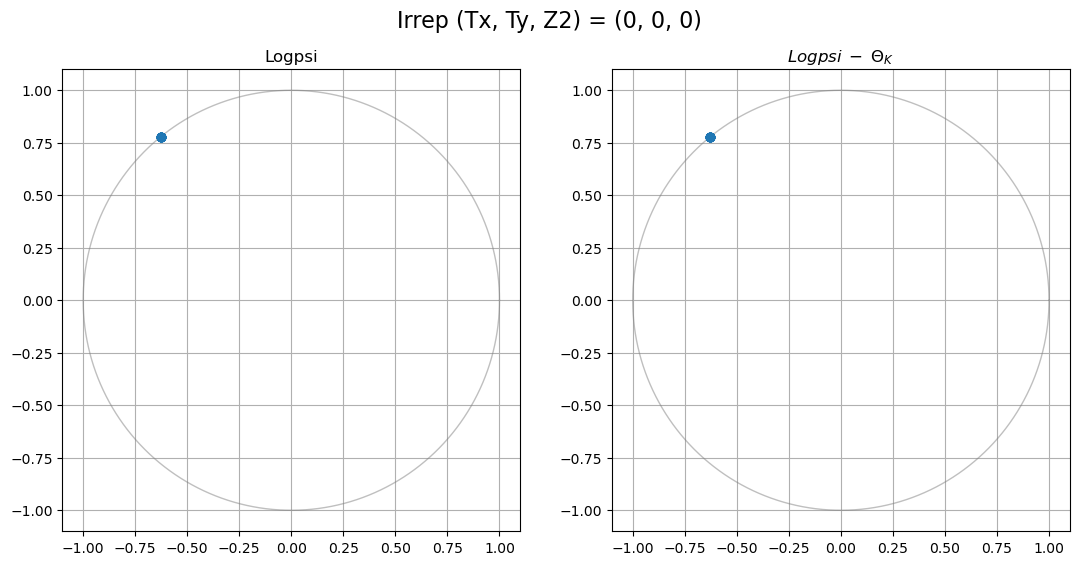


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




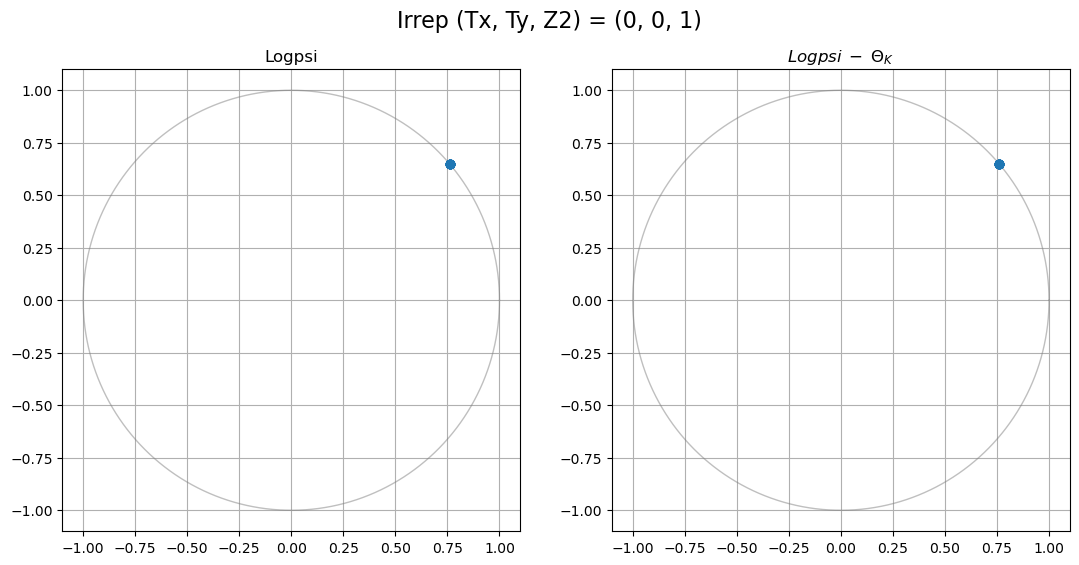


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




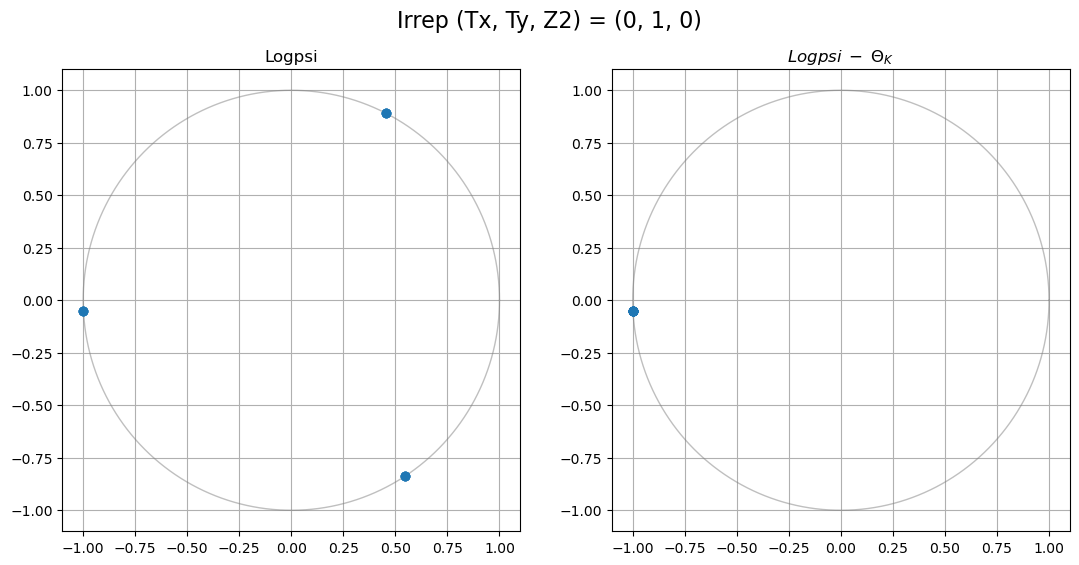


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




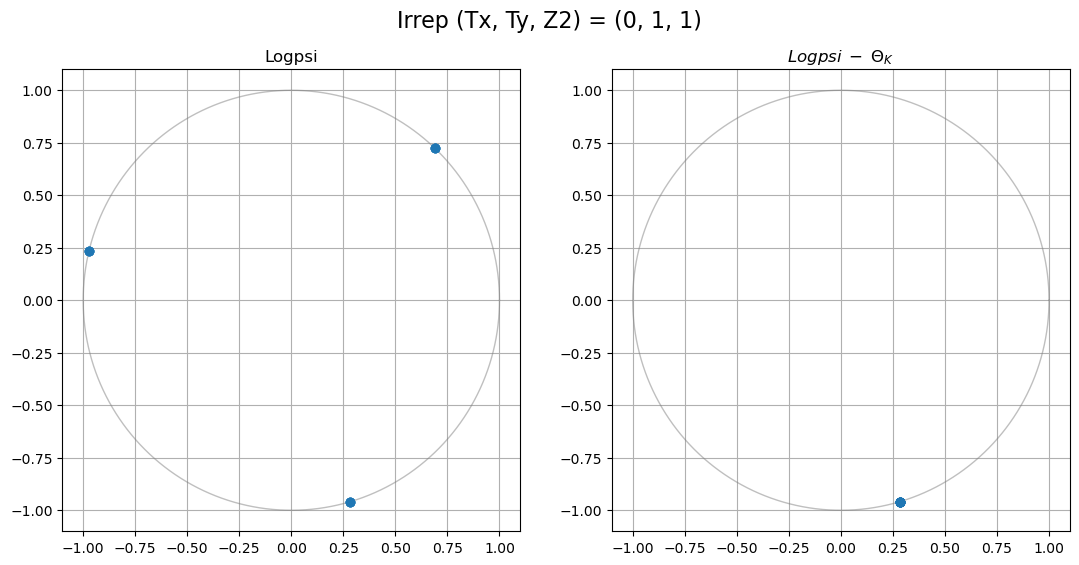


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




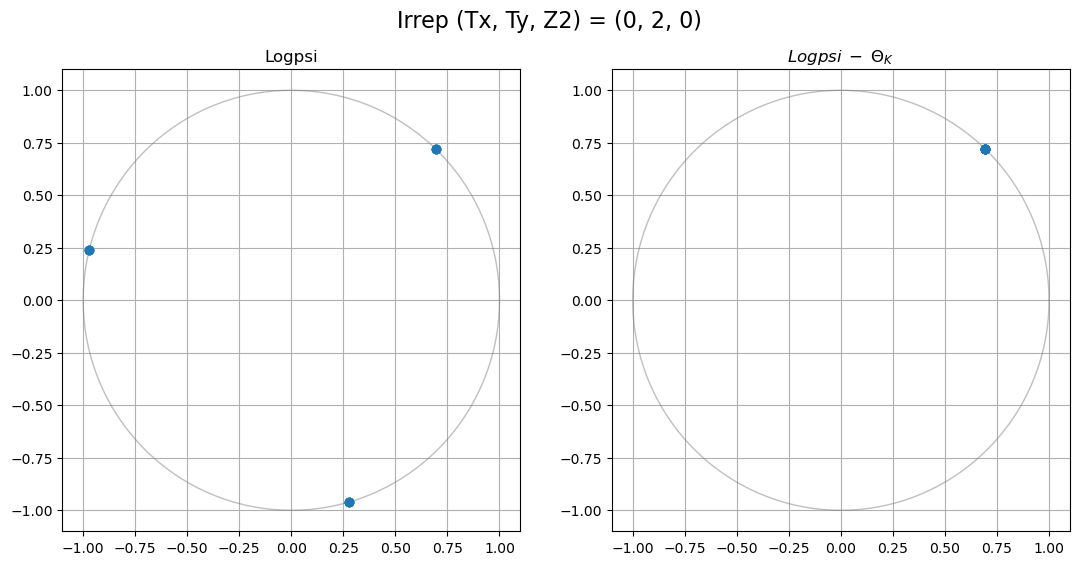


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




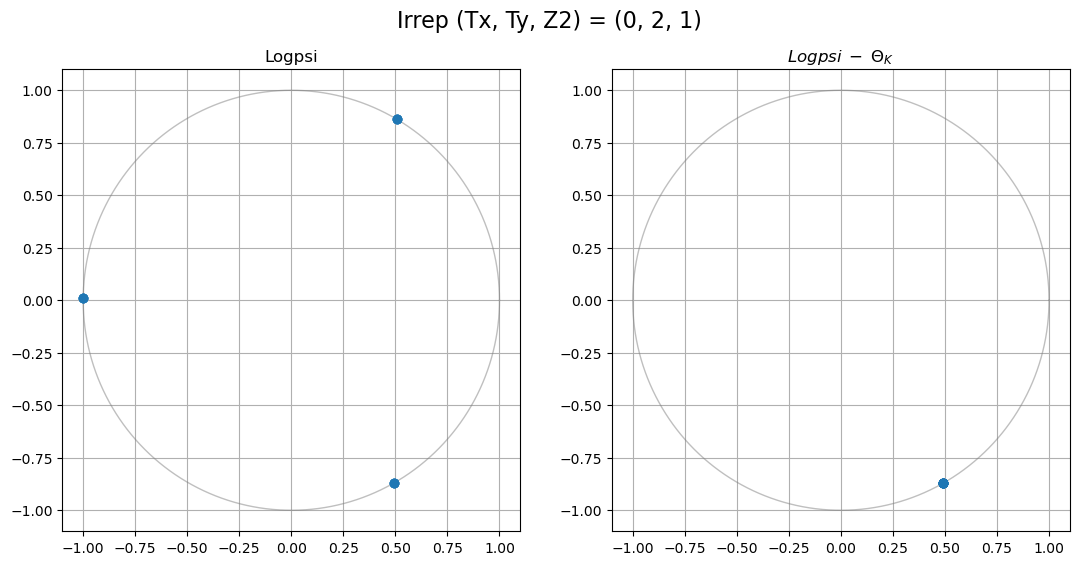


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




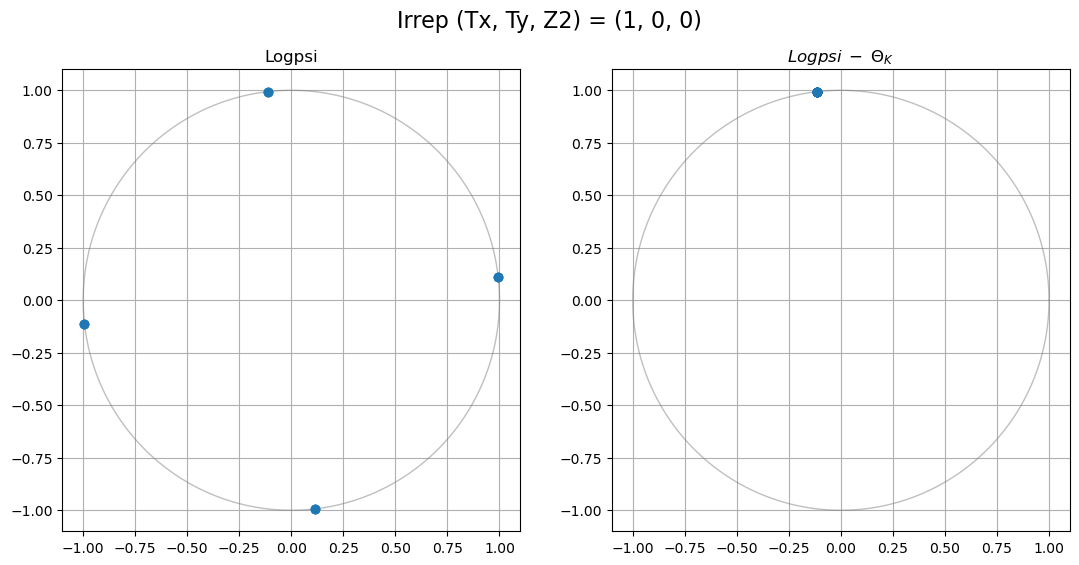


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




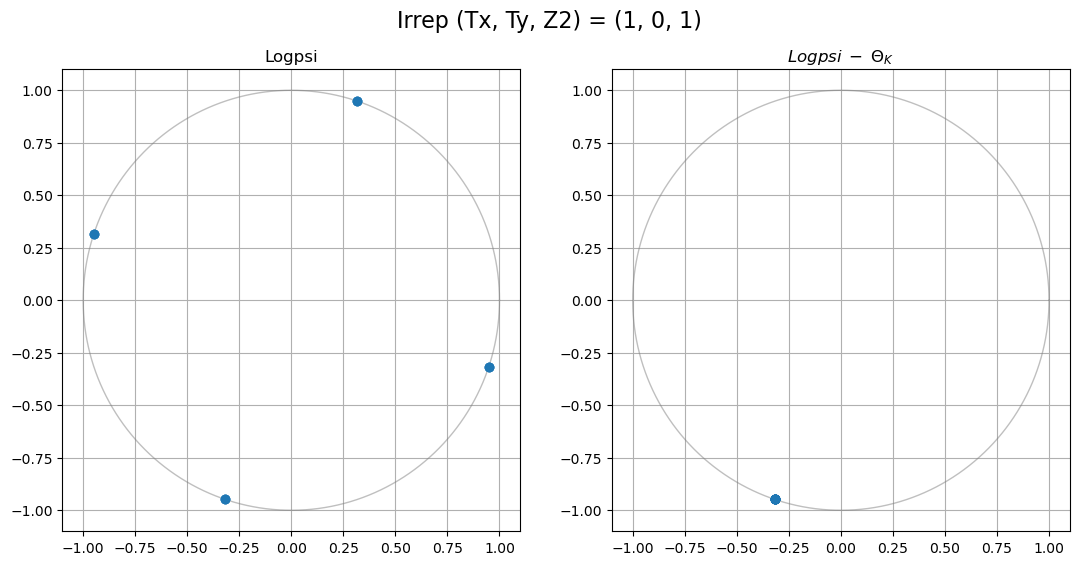


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




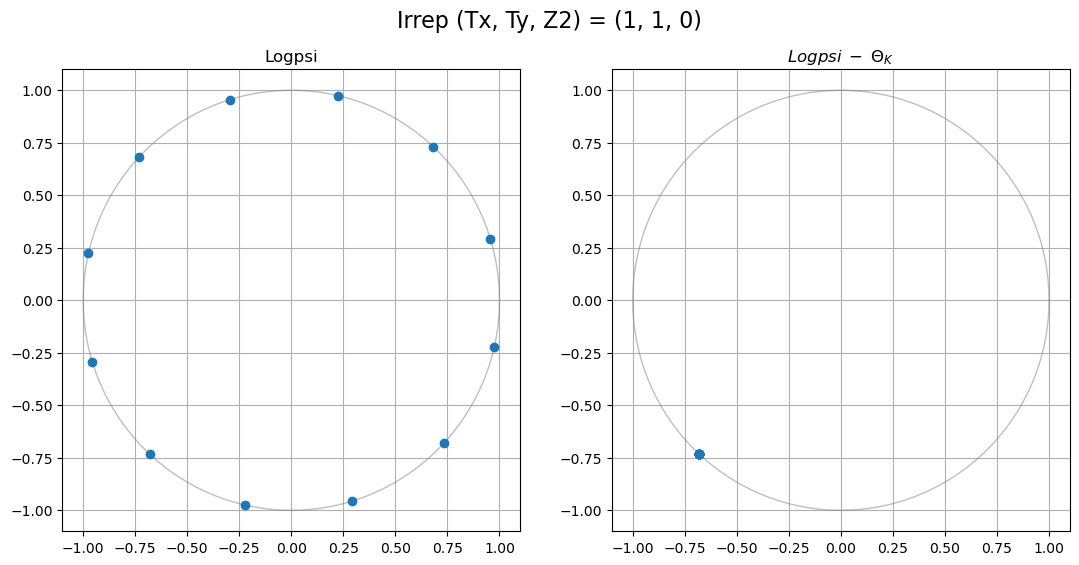


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




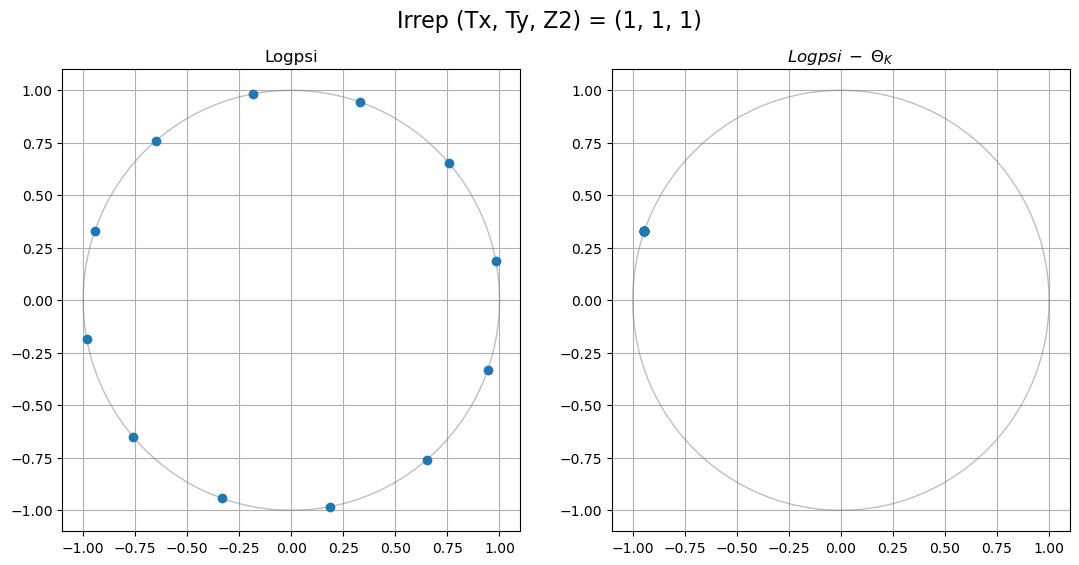


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




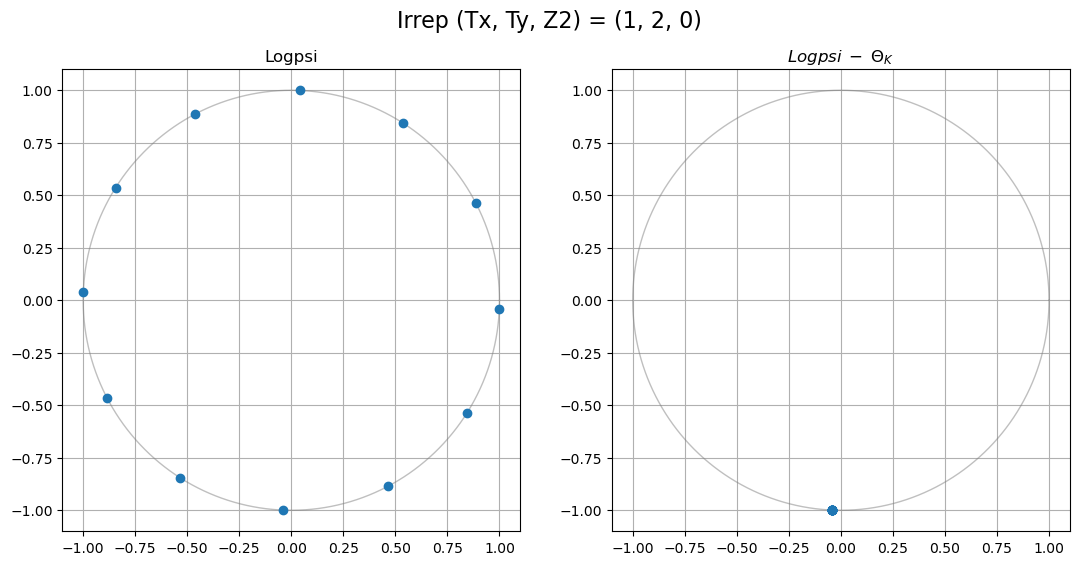


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




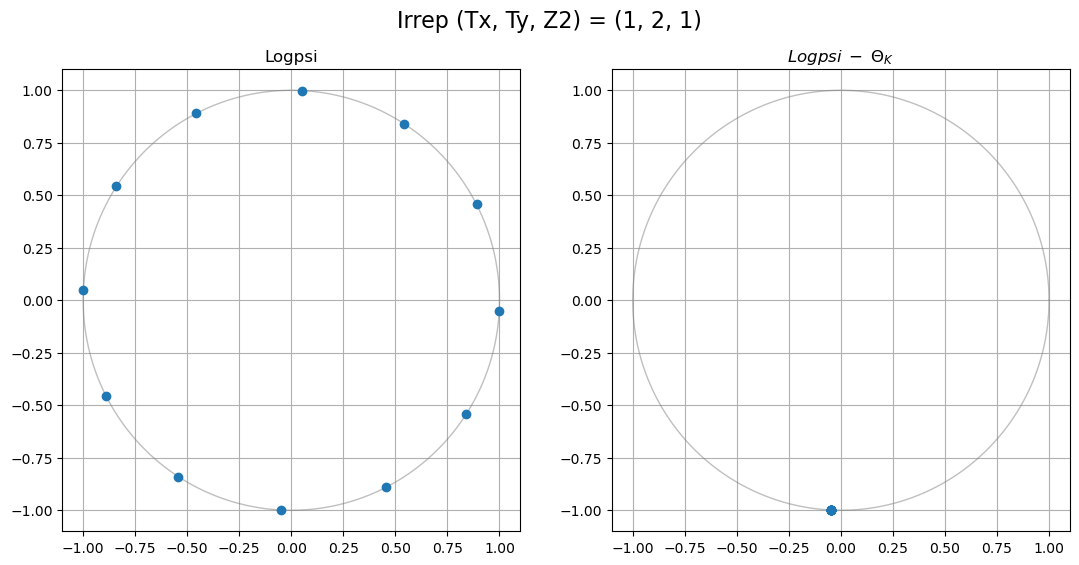


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




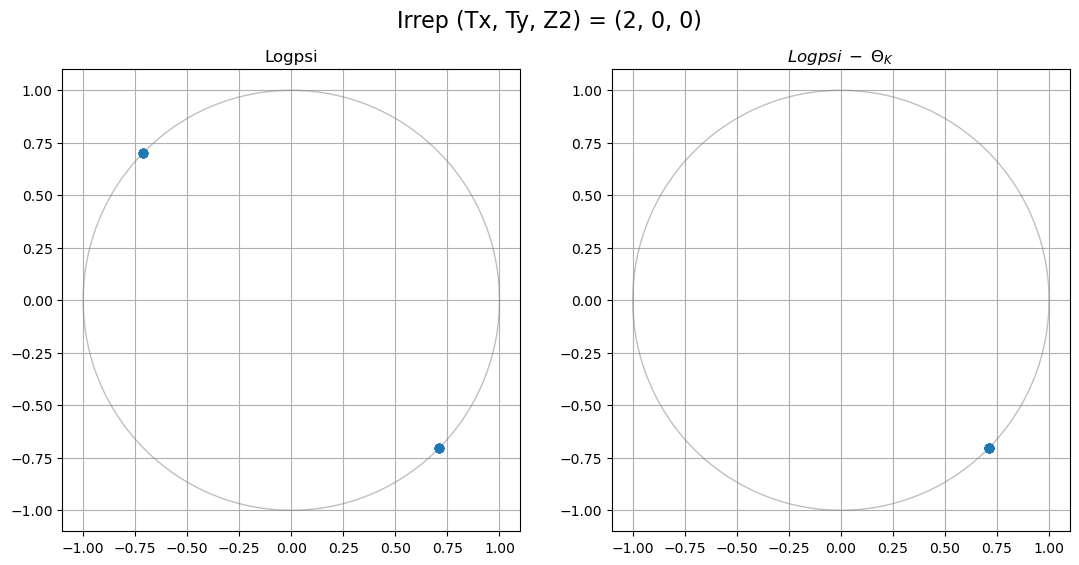


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




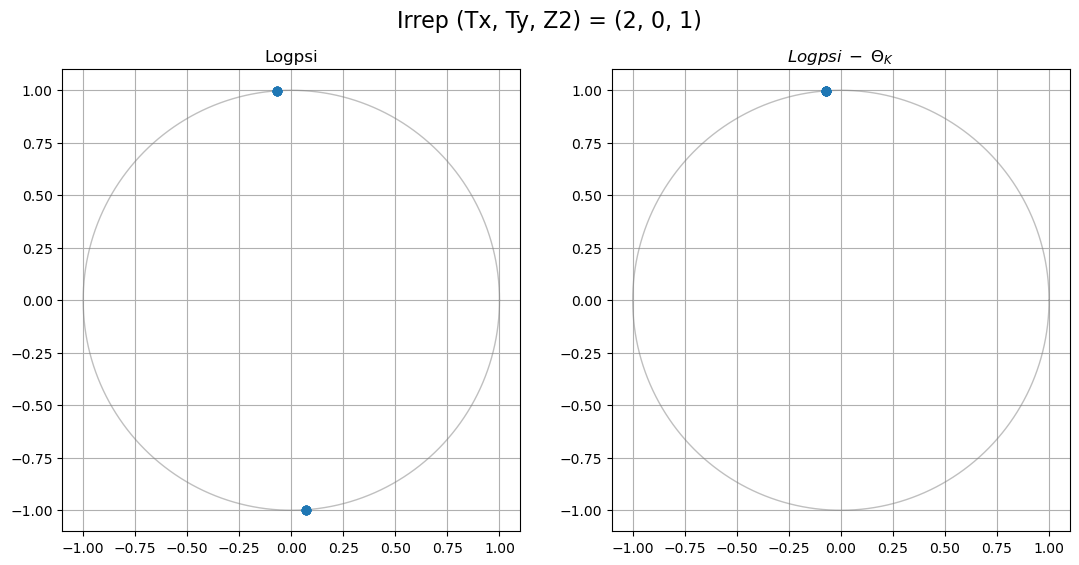


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




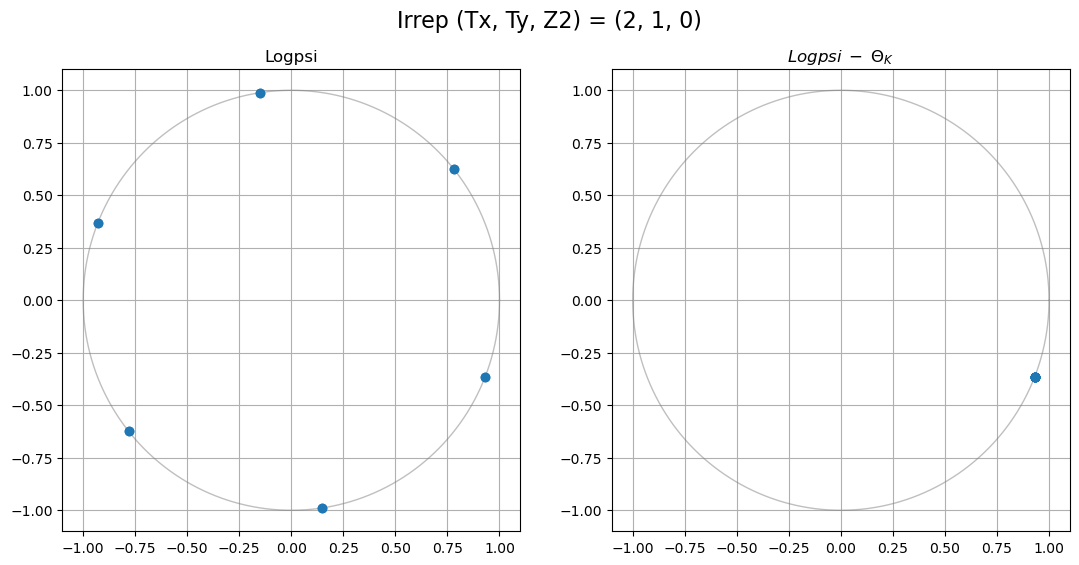


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




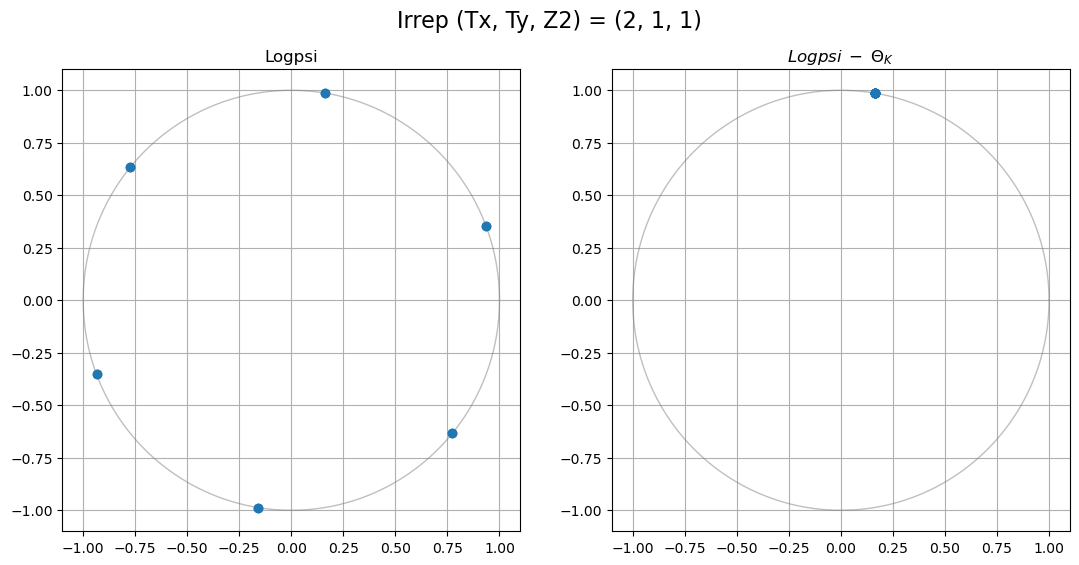


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




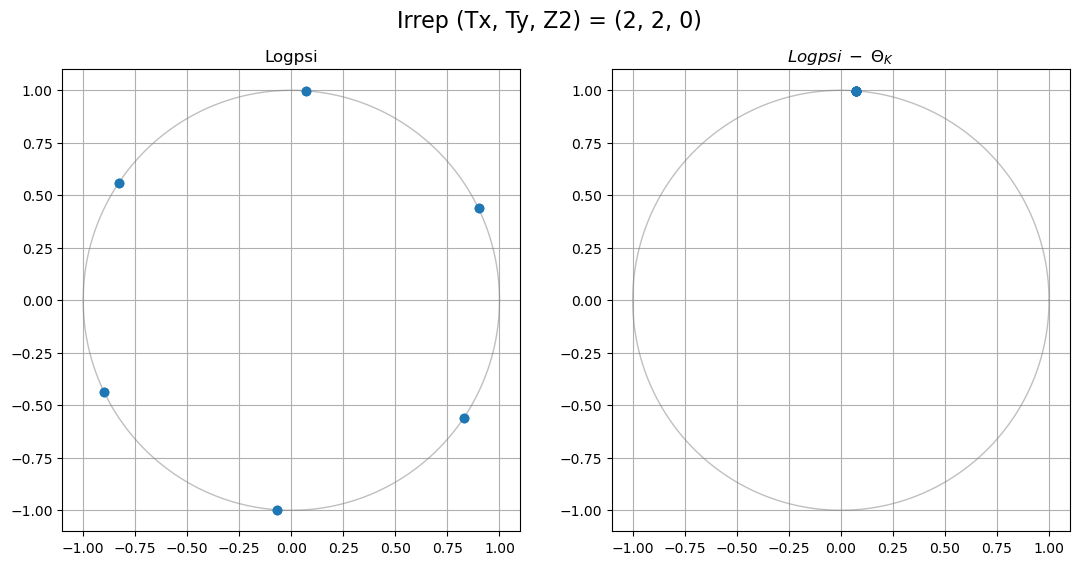


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




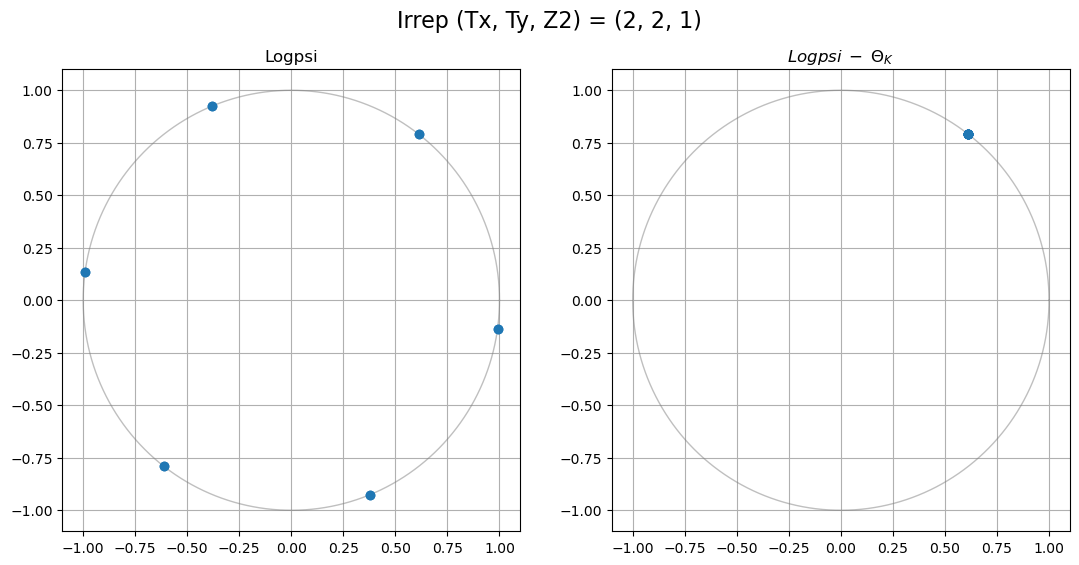


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




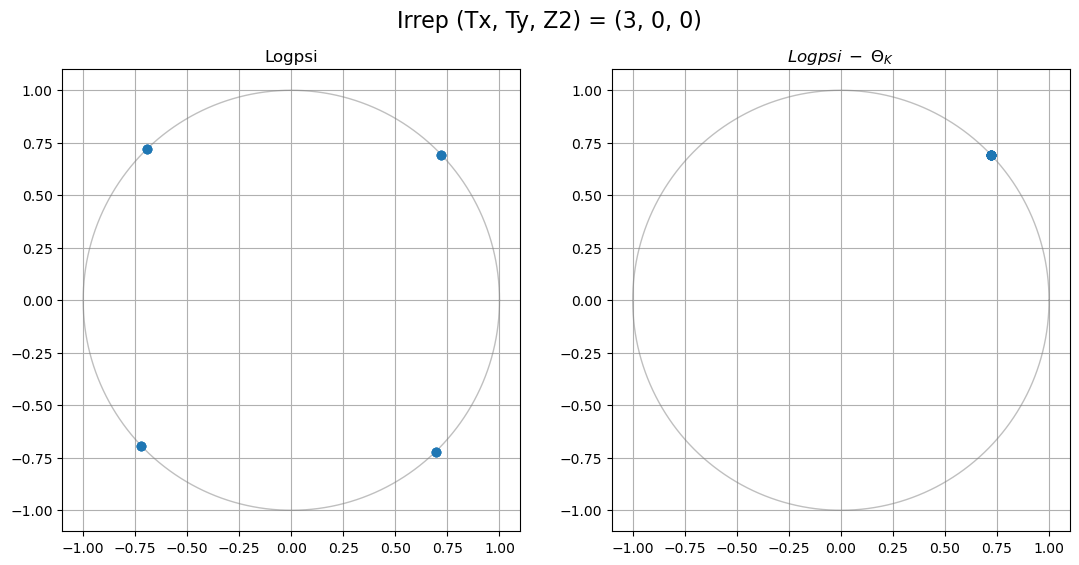


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




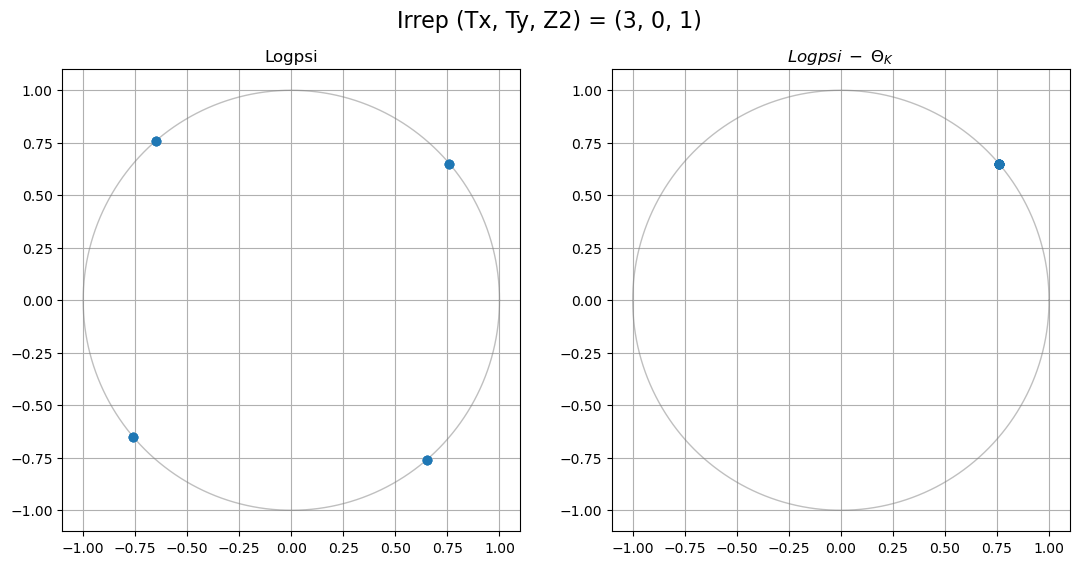


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




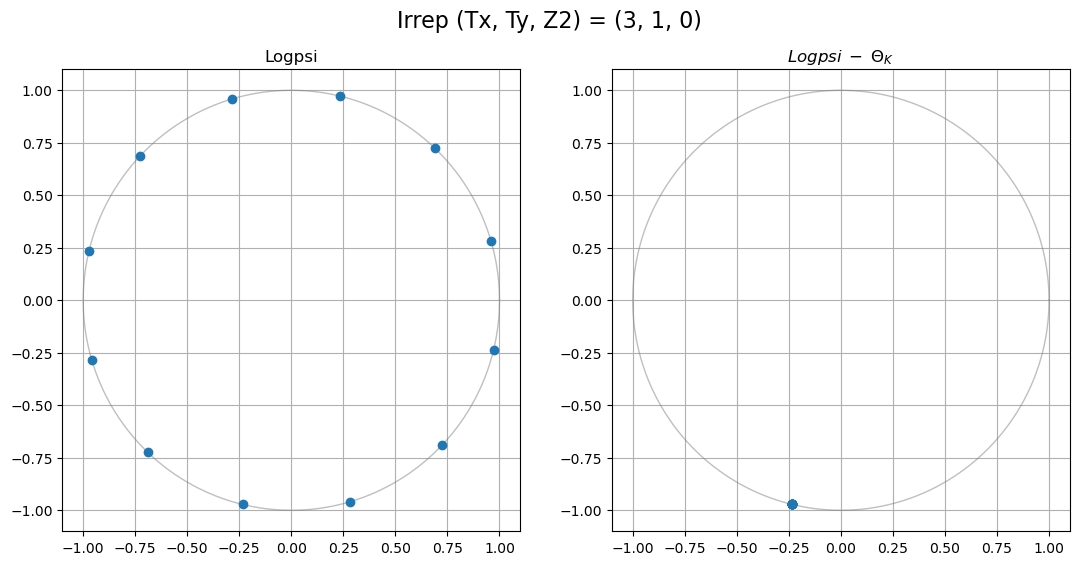


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




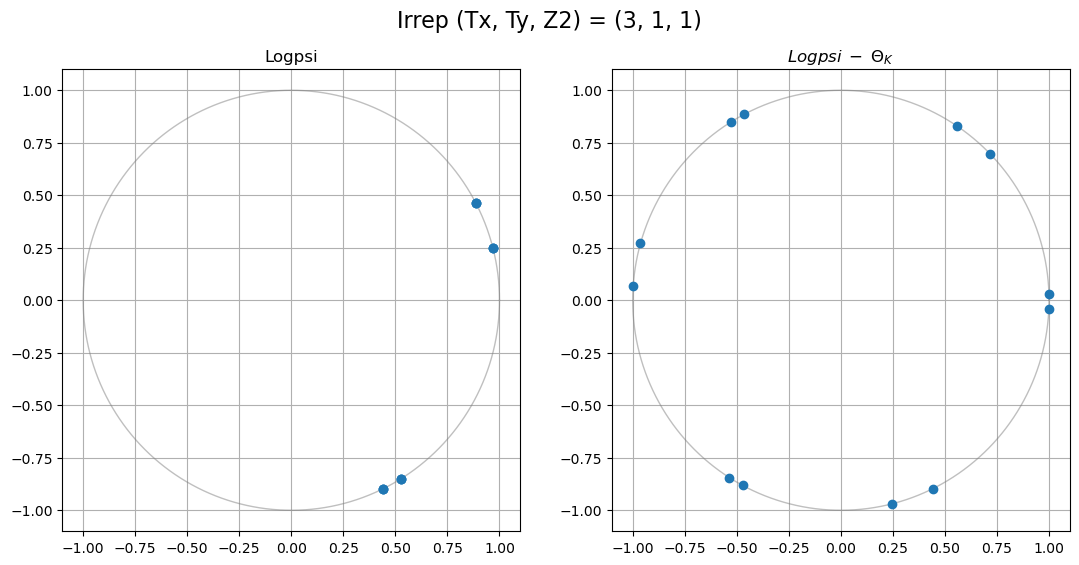


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




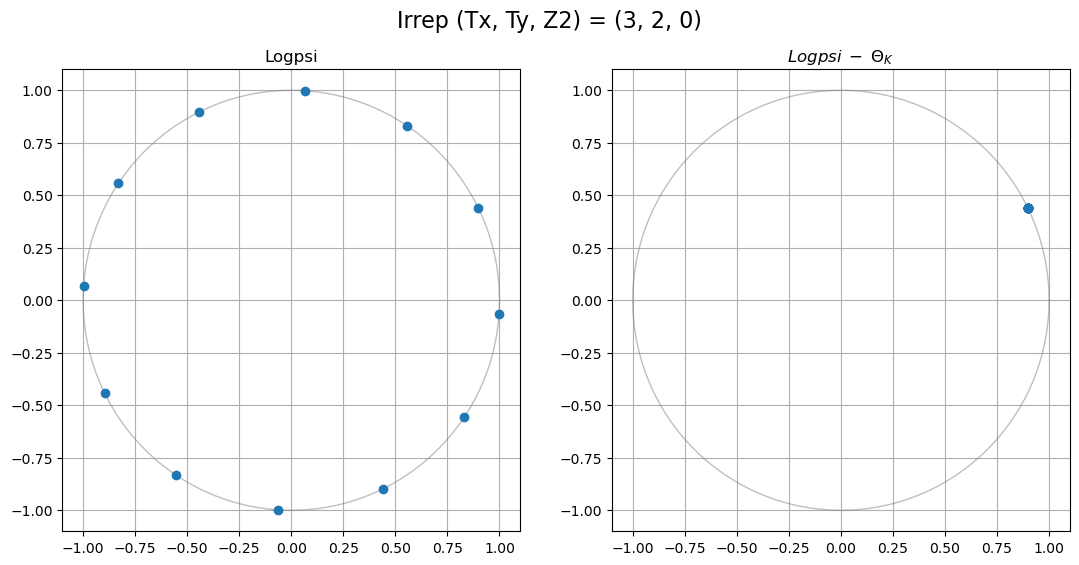


Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped




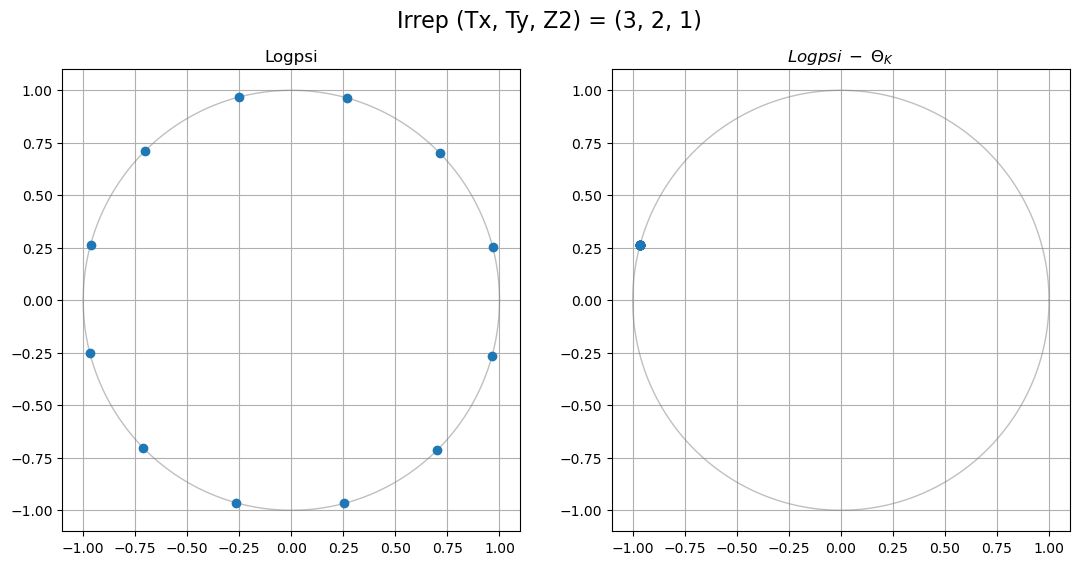

In [121]:
J = -2.5
# irrep = (2, 1, 0)


sim_path = f"/home/ihuarte/Escritorio/Ivan/NNs/Simulations_irreps_4x3/IsingSquare/"
irreps = product(range(4), range(3), range(2))


for irrep in irreps:
    irrep_str = f"{irrep[0]}{irrep[1]}{irrep[2]}"
    artifact_path = glob.glob(sim_path + f"TestViT2DOH{irrep_str}_Sequivariant_ViT2D_OutputHead_irrep/**/*ZZ_{J:.1f}*.json", recursive=True)[0]


    with open(artifact_path, "r") as f:
        artifact = json.load(f)

    vstate = load_vstate(artifact)


    size = artifact["CM"]["size"]
    N = size[0] * size[1] 

    model = vstate.model
    variables = vstate.variables


    # TRANSLATIONS, FEED FORWARD AND PHASE CORRECTIONS

    key = jax.random.PRNGKey(int(time.time()))
    x0 = jax.random.choice(key, jnp.array([-1, 1]), shape=size)[None, ..., None]
    x_trans = Translations2D(x0).reshape(N, N)
    log_psi = []
    log_psi_corrected = []
    shifts = product(range(size[0]), range(size[1]))
    for x, shift in zip(x_trans, shifts):
        x_out = vstate.model.apply(variables, x[None, :])
        phase_k =   2j * jnp.pi * (irrep[0] * shift[0] / size[0] + irrep[1] * shift[1] / size[1]) 
        x_out_2 = x_out - phase_k
        log_psi.append(x_out)
        log_psi_corrected.append(x_out_2)
        # print(shift)
        # print(f"OUT: {x_out}")
        # print(f"O_K: {phase_k}")
        # print(f"COUT: {x_out_2}")
        # print("\n")


    X = [jnp.cos(psi.imag) for psi in log_psi]
    Y = [jnp.sin(psi.imag) for psi in log_psi]

    XC = [jnp.cos(psi.imag) for psi in log_psi_corrected]
    YC = [jnp.sin(psi.imag) for psi in log_psi_corrected]


    # PLOTS

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,6))
    fig.suptitle(f"Irrep (Tx, Ty, Z2) = {irrep}", fontsize=16)

    theta = np.linspace(0, 2*np.pi, 1000)
    circle = np.array([np.cos(theta), np.sin(theta)])
    ax1.plot(circle[0], circle[1], lw=1, color="grey", alpha=0.5)
    ax2.plot(circle[0], circle[1], lw=1, color="grey", alpha=0.5)


    ax1.plot(X,Y, ls="", marker='o')
    ax1.grid()
    ax1.set_title("Logpsi")
    ax1.set_xlim(-1.1, 1.1)
    ax1.set_ylim(-1.1, 1.1)

    ax2.plot(XC,YC, ls="", marker='o')
    ax2.grid()
    ax2.set_title(r"$Logpsi\; - \; \Theta_K$")
    ax2.set_xlim(-1.1, 1.1)
    ax2.set_ylim(-1.1, 1.1)
    plt.show()

    plt.close()


(0, 0)
OUT: [5.71860804-1.34278476j]
O_K: 0j
COUT: [5.71860804-1.34278476j]


(0, 1)
OUT: [5.71860804+0.75161034j]
O_K: 2.0943951023931953j
COUT: [5.71860804-1.34278476j]


(0, 2)
OUT: [5.71860804+2.84600545j]
O_K: 4.1887902047863905j
COUT: [5.71860804-1.34278476j]


(1, 0)
OUT: [5.71860804+1.7988079j]
O_K: 3.141592653589793j
COUT: [5.71860804-1.34278476j]


(1, 1)
OUT: [5.71860804-2.38998231j]
O_K: 5.235987755982988j
COUT: [5.71860804-7.62597007j]


(1, 2)
OUT: [5.71860804-0.29558721j]
O_K: 7.330382858376183j
COUT: [5.71860804-7.62597007j]


(2, 0)
OUT: [5.71860804-1.34278476j]
O_K: 6.283185307179586j
COUT: [5.71860804-7.62597007j]


(2, 1)
OUT: [5.71860804+0.75161034j]
O_K: 8.377580409572781j
COUT: [5.71860804-7.62597007j]


(2, 2)
OUT: [5.71860804+2.84600545j]
O_K: 10.471975511965976j
COUT: [5.71860804-7.62597007j]


(3, 0)
OUT: [5.71860804+1.7988079j]
O_K: 9.42477796076938j
COUT: [5.71860804-7.62597007j]


(3, 1)
OUT: [5.71860804-2.38998231j]
O_K: 11.519173063162574j
COUT: [5.71860

# Check ED_irrep fidelity

In [28]:
J = -1.5
irrep_vs = f"101"
x_vs_path = f"/home/ihuarte/Escritorio/Ivan/NNs/Simulations_irreps_3/IsingSquare/"
x_vs_path = glob.glob(x_vs_path + f"TestViT2DOH{irrep_vs}_Sequivariant_ViT2D_OutputHead_irrep/**/*ZZ_{J:.1f}*.json", recursive=True)[0]

with open(x_vs_path, "r") as f:
    artifact = json.load(f)

vstate = load_vstate(artifact)

all_irreps =  product(range(4), range(2), range(2))

for irrep in all_irreps:
    print(f"VS: ({irrep_vs[0]}, {irrep_vs[1]}, {irrep_vs[2]})  ||  ED: {irrep}")
    x_ED_path = f"/home/ihuarte/Escritorio/Ivan/NNs/Irreps/Figures/IsingSquare/Size_4x2/GroundState__J_{J:.2f}_irrep_{str(irrep)}.txt"

    x_ED = np.loadtxt(x_ED_path, dtype=complex)

    fid = float(jnp.abs(jnp.vdot(vstate.to_array(), x_ED.squeeze())))
    print(f"Fid: {fid}\n")



Building Neural Network from setup...

Getting wrapped model for symmetrization...
Model built and wrapped


VS: (1, 0, 1)  ||  ED: (0, 0, 0)
Fid: 1.5700924586837752e-16

VS: (1, 0, 1)  ||  ED: (0, 0, 1)
Fid: 0.9717467061727219

VS: (1, 0, 1)  ||  ED: (0, 1, 0)
Fid: 4.458770163939839e-17

VS: (1, 0, 1)  ||  ED: (0, 1, 1)
Fid: 2.561636030794556e-05

VS: (1, 0, 1)  ||  ED: (1, 0, 0)
Fid: 2.9355789820816757e-18

VS: (1, 0, 1)  ||  ED: (1, 0, 1)
Fid: 0.007171166089199499

VS: (1, 0, 1)  ||  ED: (1, 1, 0)
Fid: 2.2061915819741345e-19

VS: (1, 0, 1)  ||  ED: (1, 1, 1)
Fid: 2.6840714915330466e-06

VS: (1, 0, 1)  ||  ED: (2, 0, 0)
Fid: 4.231486666465192e-17

VS: (1, 0, 1)  ||  ED: (2, 0, 1)
Fid: 3.035464116493248e-05

VS: (1, 0, 1)  ||  ED: (2, 1, 0)
Fid: 4.561170951199808e-17

VS: (1, 0, 1)  ||  ED: (2, 1, 1)
Fid: 1.0664866144162214e-06

VS: (1, 0, 1)  ||  ED: (3, 0, 0)
Fid: 2.3416883480637864e-17

VS: (1, 0, 1)  ||  ED: (3, 0, 1)
Fid: 2.008305583769658e-17

VS: (1, 0, 1)  ||  ED: (3, 1, 0)
F

/home/ihuarte/miniconda3/envs/conda_env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/jax_array_handlers.py:711: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


In [15]:
fid

2.636959043260873e-15

In [5]:
params = vstate.parameters
apply_fun = vstate._apply_fun
samples = vstate.samples

log_psi = vstate.log_value(samples)


In [11]:
E_loc = vstate.local_estimators(H)

In [ ]:
jnp.isclose

Array([[ 2.07621246e+00+1.57322687e+00j],
       [-2.12160883e+00+4.70354192e+00j],
       [-3.47270684e+00-2.71495890e+00j],
       [-1.75680163e+00+2.38627537e+00j],
       [ 2.70321587e+00+1.02426444e+00j],
       [ 3.05410598e+00+5.47974050e-01j],
       [ 2.65343303e-14-3.39173134e-14j],
       [-4.20260449e+00-8.59296145e-01j],
       [-1.85861361e+00+4.65802861e+00j],
       [-1.23460814e+00-1.78143186e-03j],
       [-1.36740901e+00+3.90354979e+00j],
       [-1.08995888e+00-5.28768248e+00j],
       [-1.02204647e+01-4.94089068e+00j],
       [ 6.34758288e-01-5.86908529e-01j],
       [-1.13711968e+00+1.93262350e+00j],
       [-4.16307225e+00+4.79799812e+00j],
       [ 8.18664679e-01-3.36280785e+00j],
       [-6.57260463e-01+1.30532094e+00j],
       [-6.47456255e+00+1.24886746e+00j],
       [ 2.56900546e+00-1.58052077e-01j],
       [-2.24463867e-01+1.77656215e-01j],
       [-1.43427117e+00-2.68168717e+00j],
       [-2.19399876e+00+2.34484188e+00j],
       [-1.13212650e+00-2.01822223

(0, 0, 0): [-9.0478142  -5.77659474 -5.21997519 -4.89045459 -4.62729973 -2.04269789]
(0, 0, 1): [-7.46941024 -3.96803002 -3.4539603  -3.27383623 -3.17297349 -3.17297349]
(0, 1, 0): [-5.40935573 -5.15007283 -4.91711696 -4.71165713 -1.65770591 -1.42348621]
(0, 1, 1): [-7.12726336 -3.57261758 -3.35216922 -3.13159407 -3.06821649 -3.00517473]
(0, 2, 0): [-5.40935573 -5.15007283 -4.91711696 -4.71165713 -1.65770591 -1.42348621]
(0, 2, 1): [-7.12726336 -3.57261758 -3.35216922 -3.13159407 -3.06821649 -3.00517473]
(1, 0, 0): [-5.40935573 -5.15007283 -4.91711696 -4.71165713 -1.65770591 -1.42348621]
(1, 0, 1): [-7.12726336 -3.57261758 -3.35216922 -3.13159407 -3.06821649 -3.00517473]
(1, 1, 0): [-5.23508022 -5.08014303 -4.92789546 -4.67023324 -1.53339555 -1.37280679]
(1, 1, 1): [-6.8374538  -3.45318099 -3.24344133 -3.21638463 -3.1296838  -3.01417962]
(1, 2, 0): [-5.23508022 -5.08014303 -4.92789546 -4.67023324 -1.53339555 -1.37280679]
(1, 2, 1): [-6.8374538  -3.45318099 -3.24344133 -3.21638463 -3.12

Text(0, 0.5, 'Energy')

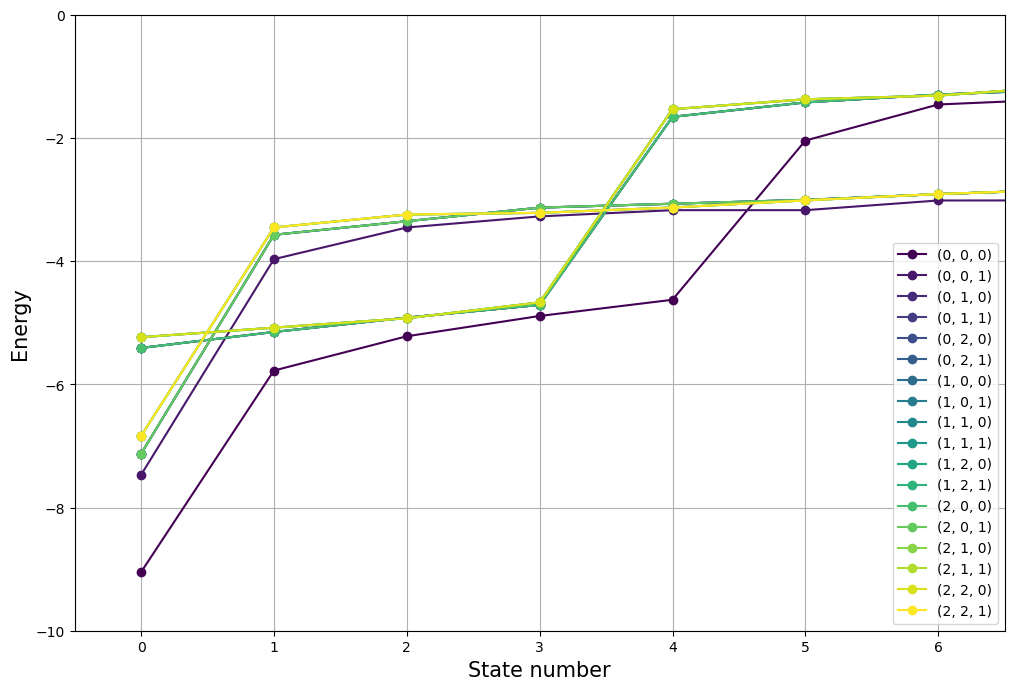

In [27]:
from itertools import product
indexes = list(product(range(3), range(3), range(2)))

fig, ax = plt.subplots(figsize=[12,8])

cmap = plt.get_cmap("viridis")(np.linspace(0, 1, len(indexes)))

for i, index in enumerate(indexes):
    E_spec = np.loadtxt(f"/home/ihuarte/Escritorio/Ivan/NNs/Irreps/Figures/IsingSquare/Size_3x3/Spectrum__J_-0.10_irrep_{index}.txt", dtype=float)
    print(f"{index}: {E_spec[:6]}")
    ax.plot(range(len(E_spec)), E_spec, color=cmap[i], marker='o', label=f"{index}")

ax.grid()
ax.legend()

ax.set_xlim(-0.5, 6.5)
ax.set_ylim(-10, 0)
ax.set_xlabel(f"State number", fontsize=15)
ax.set_ylabel(f"Energy", fontsize=15)

/tmp/ipykernel_188900/3017696273.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(x, y, 'k-', lw=0.8,  ls='--' , alpha = 0.5)
/tmp/ipykernel_188900/3017696273.py:40: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(x, y, 'k-', lw=1, ls='--' , alpha = 0.5)
/tmp/ipykernel_188900/3017696273.py:49: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(x, y, 'k-', lw=0.4, ls='--', alpha = 0.5)


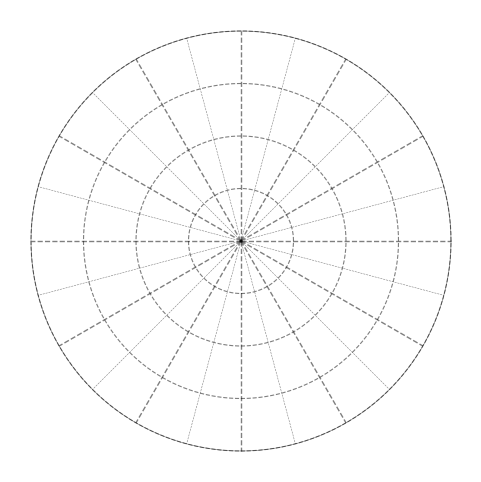

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Radio de la esfera
R = 1.0

fig, ax = plt.subplots(figsize=(6, 6))

# --------------------
# Lineas de theta = cte (circulos)
# --------------------
theta_vals = np.linspace(0, np.pi/2, 5)

phi = np.linspace(0, 2*np.pi, 500)

for theta in theta_vals:
    r = R * theta / (np.pi/2)

    x = r * np.cos(phi)
    y = r * np.sin(phi)

    ax.plot(x, y, 'k-', lw=0.8,  ls='--' , alpha = 0.5)


# --------------------
# Lineas de phi = cte (radiales)
# --------------------
phi_vals1 = np.linspace(0, 2*np.pi, 24, endpoint=False)[::2]
phi_vals2 = np.linspace(0, 2*np.pi, 24, endpoint=False)[1::2]

theta = np.linspace(0, np.pi/2, 200)

for phi0 in phi_vals1:

    r = R * np.sin(theta)

    x = r * np.cos(phi0)
    y = r * np.sin(phi0)

    ax.plot(x, y, 'k-', lw=1, ls='--' , alpha = 0.5)

for phi0 in phi_vals2:

    r = R * np.sin(theta)

    x = r * np.cos(phi0)
    y = r * np.sin(phi0)

    ax.plot(x, y, 'k-', lw=0.4, ls='--', alpha = 0.5)


# Borde del hemisferio (ecuador)
phi = np.linspace(0, 2*np.pi, 500)
x = R * np.cos(phi)
y = R * np.sin(phi)

ax.plot(x[::], y[::], 'k', lw=0.5, alpha = 0.5)

ax.set_aspect('equal')
ax.axis('off')

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

plt.savefig(
    "grid.png",
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
    dpi=300
)

In [1]:
%run ./VMC_simulation.py



∣NK⟩ Tip: Prefer the new nk.driver.VMC_SR over VMC which supports minSR and SPRING.

Ranks: 1
Devices: [CudaDevice(id=0)]
Devices: 1
Configurations:
 - /home/ihuarte/Escritorio/Ivan/NNs/config0.json
 - /home/ihuarte/Escritorio/Ivan/NNs/config1_CM.json
 - /home/ihuarte/Escritorio/Ivan/NNs/config2_Hydra.json
 - /home/ihuarte/Escritorio/Ivan/NNs/config3_Hydra_NN.json
Running exact diagonalization...
Energy ED: -3.044568059093872


───────────────────────────────────── 🧲 CM: Oxalate   🧠 NN: CvTOHStrideLog ──────────────────────────────────────

🧱 Size: 4x4

╭────────────────────────────────────────────────── SIMULATION ───────────────────────────────────────────────────╮
│ ╭────────────── Sampler ───────────────╮  ╭────────────── Schedule ──────────────╮                              │
│ │ rules=             prules= [0.8,     │  │ learning_rate=           sampler= {} │                              │
│ │ ['Exchange',       0.2]              │  │ {'epochs_struct':                    │                              │
│ │ 'LocalRule']                         │  │ [[[1000, 500]]],                     │                              │
│ │ n_ranks=           n_chains_per_ran… │  │ 'modes_struct':...                   │                              │
│ │                    2048              │  ╰──────────────────────────────────────╯                              │
│ │ n_samples_per_ch…  chunk_vstate=     │                                                                        │
│ │ 1                  1024              │                                                                        │
│ ╰──────────────────────────────────────╯                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────── COUPLING MODEL (Oxalate) ────────────────────────────────────────────╮
│ params= {'couplings': [0.2, 90.0, 115.2]}  kwargs_lattice= {'bc': 'periodic', 'order':       S_operators= False │
│                                            'default_2'}                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── NEURAL NETWORK (CvTOHStrideLog) ────────────────────────────────────────╮
│ name= CvTOHStrideLog  setup= {'stage0': {'template': {'Sequential': {'CvT': {},...                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

────────────────────────────────────────────────────────  ─────────────────────────────────────────────────────────


Building Neural Network from setup...

module: Sequential
setup
   Seq_0
      module: CvT
      setup
         n_CP_blocks: (1, 1)
         channels: (60, 60)
         attn_heads: (10, 10)
         kernel: (3, 3)
         final_architecture: None
         lattice_size: (4, 4)
   Seq_1
      module: OutputHead
      setup
         d_model: 60
         only_phase: False
Getting wrapped model for symmetrization...
Model built and wrapped
********************* ARCHITECTURE INFO *********************

No symmetrization
SymmModel:
├── Seq_0   --->  (0)
│   ├── StageBlock_0   --->  (00)
│   │   ├── Conv_0   --->  (000)
│   │   │   ├── kernel   --->  (0000)
│   │   │   └── bias   --->  (0001)
│   │   ├── LayerNorm_0   --->  (001)
│   │   │   ├── scale   --->  (0010)
│   │   │   └── bias   --->  (0011)
│   │   └── ConvProjectionBlock_0   --->  (002)
│   │       ├── DepthPointwiseConv_0   --->  (0020)
│   │       │   ├── Conv_0   --->  (00200)
│   │       │   │   └── kernel   --->  (002000)
│ 

In [18]:
np.set_printoptions(linewidth=200)
ms =vstate.samples.reshape(-1, 16).sum(axis=1)
counts, x = np.histogram(ms, bins=np.arange(-16.5, 16.5, 2),)
print((x+0.5).astype(int))
print(counts, sep="  ")

[-16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14  16]
[   0    0    0    0    4    9  110  625 1012  269   18    1    0    0    0    0]


In [12]:
fig, ax = plt.subplots()
ax.plot(np.arange(-16, 16, 2), counts, ls="", marker='o')
ax.grid()
plt.show()

qt.svg: Cannot open file '/home/ihuarte/miniconda3/envs/conda_env/lib/python3.12/site-packages/matplotlib/mpl-data/images/matplotlib.svg', because: No such file or directory


In [6]:
artifact_paths = {
    "CvT-CH-Stride-Log": {
        "4x5": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHStrideLog_Sequential_CvT_ComplexHead/Size_4x5/ST_1000-A_500-A/UUID_c0073791/Oxalate_CvTCHStrideLog_results_4x5_strength_0.2_theta_9.0_phi_72.0_date_20260423T031519_UUID_c0073791.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHStrideLog_Sequential_CvT_ComplexHead/Size_4x5/ST_1000-A_500-A/UUID_2d118f72/Oxalate_CvTCHStrideLog_results_4x5_strength_0.2_theta_9.0_phi_72.0_date_20260424T104314_UUID_2d118f72.json"
        },
        "4x6": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHStrideLog_Sequential_CvT_ComplexHead/Size_4x6/ST_1000-A_500-A/UUID_2fee3c29/Oxalate_CvTCHStrideLog_results_4x6_strength_0.2_theta_9.0_phi_72.0_date_20260423T131443_UUID_2fee3c29.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHStrideLog_Sequential_CvT_ComplexHead/Size_4x6/ST_1000-A_500-A/UUID_e26df7fb/Oxalate_CvTCHStrideLog_results_4x6_strength_0.2_theta_9.0_phi_72.0_date_20260425T040010_UUID_e26df7fb.json"
        },
        "6x6": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHStrideLog_Sequential_CvT_ComplexHead/Size_6x6/ST_1000-A_500-A/UUID_4618095b/Oxalate_CvTCHStrideLog_results_6x6_strength_0.2_theta_9.0_phi_72.0_date_20260424T125430_UUID_4618095b.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHStrideLog_Sequential_CvT_ComplexHead/Size_6x6/ST_1000-A_500-A/UUID_19efe26a/Oxalate_CvTCHStrideLog_results_6x6_strength_0.2_theta_9.0_phi_72.0_date_20260426T060911_UUID_19efe26a.json"
        },
        "6x8": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHStrideLog_Sequential_CvT_ComplexHead/Size_6x8/ST_1000-A_500-A/UUID_3452616c/Oxalate_CvTCHStrideLog_results_6x8_strength_0.2_theta_9.0_phi_72.0_date_20260426T001838_UUID_3452616c.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHStrideLog_Sequential_CvT_ComplexHead/Size_6x8/ST_1000-A_500-A/UUID_a8c00171/Oxalate_CvTCHStrideLog_results_6x8_strength_0.2_theta_9.0_phi_72.0_date_20260427T145054_UUID_a8c00171.json"
        }
    },
    "CvT-CH-Stride-NoLog": {
        "4x5": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHStrideNoLog_Sequential_CvT_ComplexHead/Size_4x5/ST_1000-A_500-A/UUID_42f82b99/Oxalate_CvTCHStrideNoLog_results_4x5_strength_0.2_theta_9.0_phi_72.0_date_20260419T174824_UUID_42f82b99.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHStrideNoLog_Sequential_CvT_ComplexHead/Size_4x5/ST_1000-A_500-A/UUID_576de464/Oxalate_CvTCHStrideNoLog_results_4x5_strength_0.2_theta_9.0_phi_72.0_date_20260420T142412_UUID_576de464.json"
        },
        "4x6": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHStrideNoLog_Sequential_CvT_ComplexHead/Size_4x6/ST_1000-A_500-A/UUID_f84664c2/Oxalate_CvTCHStrideNoLog_results_4x6_strength_0.2_theta_9.0_phi_72.0_date_20260420T062126_UUID_f84664c2.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHStrideNoLog_Sequential_CvT_ComplexHead/Size_4x6/ST_1000-A_500-A/UUID_28527f0e/Oxalate_CvTCHStrideNoLog_results_4x6_strength_0.2_theta_9.0_phi_72.0_date_20260421T095417_UUID_28527f0e.json"
        },
        "6x6": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHStrideNoLog_Sequential_CvT_ComplexHead/Size_6x6/ST_1000-A_500-A/UUID_3c0ea5f5/Oxalate_CvTCHStrideNoLog_results_6x6_strength_0.2_theta_9.0_phi_72.0_date_20260421T054930_UUID_3c0ea5f5.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHStrideNoLog_Sequential_CvT_ComplexHead/Size_6x6/ST_1000-A_500-A/UUID_8e76ae18/Oxalate_CvTCHStrideNoLog_results_6x6_strength_0.2_theta_9.0_phi_72.0_date_20260422T114154_UUID_8e76ae18.json"
        },
        "6x8": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHStrideNoLog_Sequential_CvT_ComplexHead/Size_6x8/ST_1000-A_500-A/UUID_def6c959/Oxalate_CvTCHStrideNoLog_results_6x8_strength_0.2_theta_9.0_phi_72.0_date_20260422T150934_UUID_def6c959.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHStrideNoLog_Sequential_CvT_ComplexHead/Size_6x8/ST_1000-A_500-A/UUID_9e52c203/Oxalate_CvTCHStrideNoLog_results_6x8_strength_0.2_theta_9.0_phi_72.0_date_20260423T192119_UUID_9e52c203.json"
        }
    },
    "CvT-CH-NoStride-Log": {
        "4x5": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHNoStrideLog_Sequential_CvT_ComplexHead/Size_4x5/ST_1000-A_500-A/UUID_e51d9ee1/Oxalate_CvTCHNoStrideLog_results_4x5_strength_0.2_theta_9.0_phi_72.0_date_20260411T032352_UUID_e51d9ee1.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHNoStrideLog_Sequential_CvT_ComplexHead/Size_4x5/ST_1000-A_500-A/UUID_d96632c0/Oxalate_CvTCHNoStrideLog_results_4x5_strength_0.2_theta_9.0_phi_72.0_date_20260410T222813_UUID_d96632c0.json"
        },
        "4x6": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHNoStrideLog_Sequential_CvT_ComplexHead/Size_4x6/ST_1000-A_500-A/UUID_24f1b301/Oxalate_CvTCHNoStrideLog_results_4x6_strength_0.2_theta_9.0_phi_72.0_date_20260411T093439_UUID_24f1b301.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHNoStrideLog_Sequential_CvT_ComplexHead/Size_4x6/ST_1000-A_500-A/UUID_3ade63c5/Oxalate_CvTCHNoStrideLog_results_4x6_strength_0.2_theta_9.0_phi_72.0_date_20260411T193433_UUID_3ade63c5.json"
        },
        "6x6": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHNoStrideLog_Sequential_CvT_ComplexHead/Size_6x6/ST_1000-A_500-A/UUID_6b3ed9d5/Oxalate_CvTCHNoStrideLog_results_6x6_strength_0.2_theta_9.0_phi_72.0_date_20260412T090838_UUID_6b3ed9d5.json"  
        },
        "6x8": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHNoStrideLog_Sequential_CvT_ComplexHead/Size_6x8/ST_1000-A_500-A/UUID_4e9d515a/Oxalate_CvTCHNoStrideLog_results_6x8_strength_0.2_theta_9.0_phi_72.0_date_20260413T195020_UUID_4e9d515a.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHNoStrideLog_Sequential_CvT_ComplexHead/Size_6x8/ST_1000-A_500-A/UUID_a75e0589/Oxalate_CvTCHNoStrideLog_results_6x8_strength_0.2_theta_9.0_phi_72.0_date_20260413T064616_UUID_a75e0589.json"
        }
    },
    "CvT-CH-NoStride-NoLog": {
        "4x5": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHNoStrideNoLog_Sequential_CvT_ComplexHead/Size_4x5/ST_1000-A_500-A/UUID_72d47747/Oxalate_CvTCHNoStrideNoLog_results_4x5_strength_0.2_theta_9.0_phi_72.0_date_20260413T200150_UUID_72d47747.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHNoStrideNoLog_Sequential_CvT_ComplexHead/Size_4x5/ST_1000-A_500-A/UUID_f0dbb067/Oxalate_CvTCHNoStrideNoLog_results_4x5_strength_0.2_theta_9.0_phi_72.0_date_20260414T011521_UUID_f0dbb067.json"
        },
        "4x6": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHNoStrideNoLog_Sequential_CvT_ComplexHead/Size_4x6/ST_1000-A_500-A/UUID_f9a6b908/Oxalate_CvTCHNoStrideNoLog_results_4x6_strength_0.2_theta_9.0_phi_72.0_date_20260414T071234_UUID_f9a6b908.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTCHNoStrideNoLog_Sequential_CvT_ComplexHead/Size_4x6/ST_1000-A_500-A/UUID_37a4dfc3/Oxalate_CvTCHNoStrideNoLog_results_4x6_strength_0.2_theta_9.0_phi_72.0_date_20260414T200414_UUID_37a4dfc3.json"
        }
    },

    "CvT-OH-Stride-Log": {
        "4x5": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHstrideLog_Sequential_CvT_OutputHead/Size_4x5/ST_1000-A_500-A/UUID_4148b619/Oxalate_CvTOHstrideLog_results_4x5_strength_0.2_theta_9.0_phi_72.0_date_20260422T223038_UUID_4148b619.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHstrideLog_Sequential_CvT_OutputHead/Size_4x5/ST_1000-A_500-A/UUID_262f41d2/Oxalate_CvTOHstrideLog_results_4x5_strength_0.2_theta_9.0_phi_72.0_date_20260422T001405_UUID_262f41d2.json"
        },
        "4x6": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHstrideLog_Sequential_CvT_OutputHead/Size_4x6/ST_1000-A_500-A/UUID_e27a7faa/Oxalate_CvTOHstrideLog_results_4x6_strength_0.2_theta_9.0_phi_72.0_date_20260423T080906_UUID_e27a7faa.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHstrideLog_Sequential_CvT_OutputHead/Size_4x6/ST_1000-A_500-A/UUID_e38b2e01/Oxalate_CvTOHstrideLog_results_4x6_strength_0.2_theta_9.0_phi_72.0_date_20260422T145730_UUID_e38b2e01.json"
        },
        "6x6": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHstrideLog_Sequential_CvT_OutputHead/Size_6x6/ST_1000-A_500-A/UUID_3ddef863/Oxalate_CvTOHstrideLog_results_6x6_strength_0.2_theta_9.0_phi_72.0_date_20260424T070120_UUID_3ddef863.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHstrideLog_Sequential_CvT_OutputHead/Size_6x6/ST_1000-A_500-A/UUID_1ead56d6/Oxalate_CvTOHstrideLog_results_6x6_strength_0.2_theta_9.0_phi_72.0_date_20260423T154552_UUID_1ead56d6.json"
        },
        "6x8": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHstrideLog_Sequential_CvT_OutputHead/Size_6x8/ST_1000-A_500-A/UUID_c9ec47cd/Oxalate_CvTOHstrideLog_results_6x8_strength_0.2_theta_9.0_phi_72.0_date_20260425T174547_UUID_c9ec47cd.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHstrideLog_Sequential_CvT_OutputHead/Size_6x8/ST_1000-A_500-A/UUID_088e6c34/Oxalate_CvTOHstrideLog_results_6x8_strength_0.2_theta_9.0_phi_72.0_date_20260425T045332_UUID_088e6c34.json"
        }
    },
    "CvT-OH-Stride-NoLog": {
        "4x5": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHstrideNoLog_Sequential_CvT_OutputHead/Size_4x5/ST_1000-A_500-A/UUID_1f4762d4/Oxalate_CvTOHstrideNoLog_results_4x5_strength_0.2_theta_9.0_phi_72.0_date_20260418T234153_UUID_1f4762d4.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHstrideNoLog_Sequential_CvT_OutputHead/Size_4x5/ST_1000-A_500-A/UUID_7da8f2c7/Oxalate_CvTOHstrideNoLog_results_4x5_strength_0.2_theta_9.0_phi_72.0_date_20260415T211017_UUID_7da8f2c7.json"
        },
        "4x6": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHstrideNoLog_Sequential_CvT_OutputHead/Size_4x6/ST_1000-A_500-A/UUID_89bd27bb/Oxalate_CvTOHstrideNoLog_results_4x6_strength_0.2_theta_9.0_phi_72.0_date_20260419T185030_UUID_89bd27bb.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHstrideNoLog_Sequential_CvT_OutputHead/Size_4x6/ST_1000-A_500-A/UUID_7c34b405/Oxalate_CvTOHstrideNoLog_results_4x6_strength_0.2_theta_9.0_phi_72.0_date_20260417T002929_UUID_7c34b405.json"
        },
        "6x6": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHstrideNoLog_Sequential_CvT_OutputHead/Size_6x6/ST_1000-A_500-A/UUID_682ae33c/Oxalate_CvTOHstrideNoLog_results_6x6_strength_0.2_theta_9.0_phi_72.0_date_20260420T214922_UUID_682ae33c.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHstrideNoLog_Sequential_CvT_OutputHead/Size_6x6/ST_1000-A_500-A/UUID_715248b7/Oxalate_CvTOHstrideNoLog_results_6x6_strength_0.2_theta_9.0_phi_72.0_date_20260418T061244_UUID_715248b7.json"
        },
        "6x8": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHstrideNoLog_Sequential_CvT_OutputHead/Size_6x8/ST_1000-A_500-A/UUID_0e46558d/Oxalate_CvTOHstrideNoLog_results_6x8_strength_0.2_theta_9.0_phi_72.0_date_20260422T115846_UUID_0e46558d.json",
        }
    },
    "CvT-OH-NoStride-Log": {
        "4x5": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHNostrideLog_Sequential_CvT_OutputHead/Size_4x5/ST_1000-A_500-A/UUID_9864eb28/Oxalate_CvTOHNostrideLog_results_4x5_strength_0.2_theta_9.0_phi_72.0_date_20260414T214813_UUID_9864eb28.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHNostrideLog_Sequential_CvT_OutputHead/Size_4x5/ST_1000-A_500-A/UUID_0cb98349/Oxalate_CvTOHNostrideLog_results_4x5_strength_0.2_theta_9.0_phi_72.0_date_20260411T062426_UUID_0cb98349.json"
        },
        "4x6": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHNostrideLog_Sequential_CvT_OutputHead/Size_4x6/ST_1000-A_500-A/UUID_6bce3d01/Oxalate_CvTOHNostrideLog_results_4x6_strength_0.2_theta_9.0_phi_72.0_date_20260415T125819_UUID_6bce3d01.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHNostrideLog_Sequential_CvT_OutputHead/Size_4x6/ST_1000-A_500-A/UUID_ec894b9a/Oxalate_CvTOHNostrideLog_results_4x6_strength_0.2_theta_9.0_phi_72.0_date_20260411T221550_UUID_ec894b9a.json"
        },
        "6x6": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHNostrideLog_Sequential_CvT_OutputHead/Size_6x6/ST_1000-A_500-A/UUID_ea3ced57/Oxalate_CvTOHNostrideLog_results_6x6_strength_0.2_theta_9.0_phi_72.0_date_20260416T161137_UUID_ea3ced57.json",
        },
        "6x8": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHNostrideLog_Sequential_CvT_OutputHead/Size_6x8/ST_1000-A_500-A/UUID_1905a17d/Oxalate_CvTOHNostrideLog_results_6x8_strength_0.2_theta_9.0_phi_72.0_date_20260418T070148_UUID_1905a17d.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHNostrideLog_Sequential_CvT_OutputHead/Size_6x8/ST_1000-A_500-A/UUID_59d08479/Oxalate_CvTOHNostrideLog_results_6x8_strength_0.2_theta_9.0_phi_72.0_date_20260413T082143_UUID_59d08479.json"
        }
    },
    "CvT-OH-NoStride-NoLog": {
        "4x5": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHNostrideNoLog_Sequential_CvT_OutputHead/Size_4x5/ST_1000-A_500-A/UUID_8dd2adbc/Oxalate_CvTOHNostrideNoLog_results_4x5_strength_0.2_theta_9.0_phi_72.0_date_20260415T172337_UUID_8dd2adbc.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHNostrideNoLog_Sequential_CvT_OutputHead/Size_4x5/ST_1000-A_500-A/UUID_ccfc52d7/Oxalate_CvTOHNostrideNoLog_results_4x5_strength_0.2_theta_9.0_phi_72.0_date_20260415T024231_UUID_ccfc52d7.json"
        },
        "4x6": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHNostrideNoLog_Sequential_CvT_OutputHead/Size_4x6/ST_1000-A_500-A/UUID_8d2d8413/Oxalate_CvTOHNostrideNoLog_results_4x6_strength_0.2_theta_9.0_phi_72.0_date_20260416T094155_UUID_8d2d8413.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHNostrideNoLog_Sequential_CvT_OutputHead/Size_4x6/ST_1000-A_500-A/UUID_35b5526b/Oxalate_CvTOHNostrideNoLog_results_4x6_strength_0.2_theta_9.0_phi_72.0_date_20260416T101410_UUID_35b5526b.json"
        },
        "6x6": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHNostrideNoLog_Sequential_CvT_OutputHead/Size_6x6/ST_1000-A_500-A/UUID_fd4c417f/Oxalate_CvTOHNostrideNoLog_results_6x6_strength_0.2_theta_9.0_phi_72.0_date_20260417T141041_UUID_fd4c417f.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHNostrideNoLog_Sequential_CvT_OutputHead/Size_6x6/ST_1000-A_500-A/UUID_ec59f98c/Oxalate_CvTOHNostrideNoLog_results_6x6_strength_0.2_theta_9.0_phi_72.0_date_20260417T233553_UUID_ec59f98c.json"
        },
        "6x8": {
            "deep": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHNostrideNoLog_Sequential_CvT_OutputHead/Size_6x8/ST_1000-A_500-A/UUID_ff23ce6e/Oxalate_CvTOHNostrideNoLog_results_6x8_strength_0.2_theta_9.0_phi_72.0_date_20260419T044411_UUID_ff23ce6e.json",
            "short": "/home/ihuarte/Escritorio/Ivan/NNs/Simulations/Oxalate/CvTOHNostrideNoLog_Sequential_CvT_OutputHead/Size_6x8/ST_1000-A_500-A/UUID_9d30d59b/Oxalate_CvTOHNostrideNoLog_results_6x8_strength_0.2_theta_9.0_phi_72.0_date_20260419T173943_UUID_9d30d59b.json"
        }
    },
}

In [7]:
energy = {}
vscore = {}
fidelity = {}
modes = []
sizes = ["4x5", "4x6", "6x6", "6x8"]

for mode, v in artifact_paths.items():
    modes.append(mode)
    energy[mode] = {}
    vscore[mode] = {}
    fidelity[mode] = {}
    for size, val in v.items():
        vscore[mode][size] = {}
        energy[mode][size] = {}
        fidelity[mode][size] = {}
        for lenght, path in val.items():

            with open(path, "r") as f:
                artifact = json.load(f)

            E = artifact["results"]["E_best_per_site"] 
            vs = artifact["results"]["vscore"]
            fid = artifact["results"]["fidelity"]  

            energy[mode][size][lenght] = E
            vscore[mode][size][lenght] = vs
            fidelity[mode][size][lenght] = fid


            

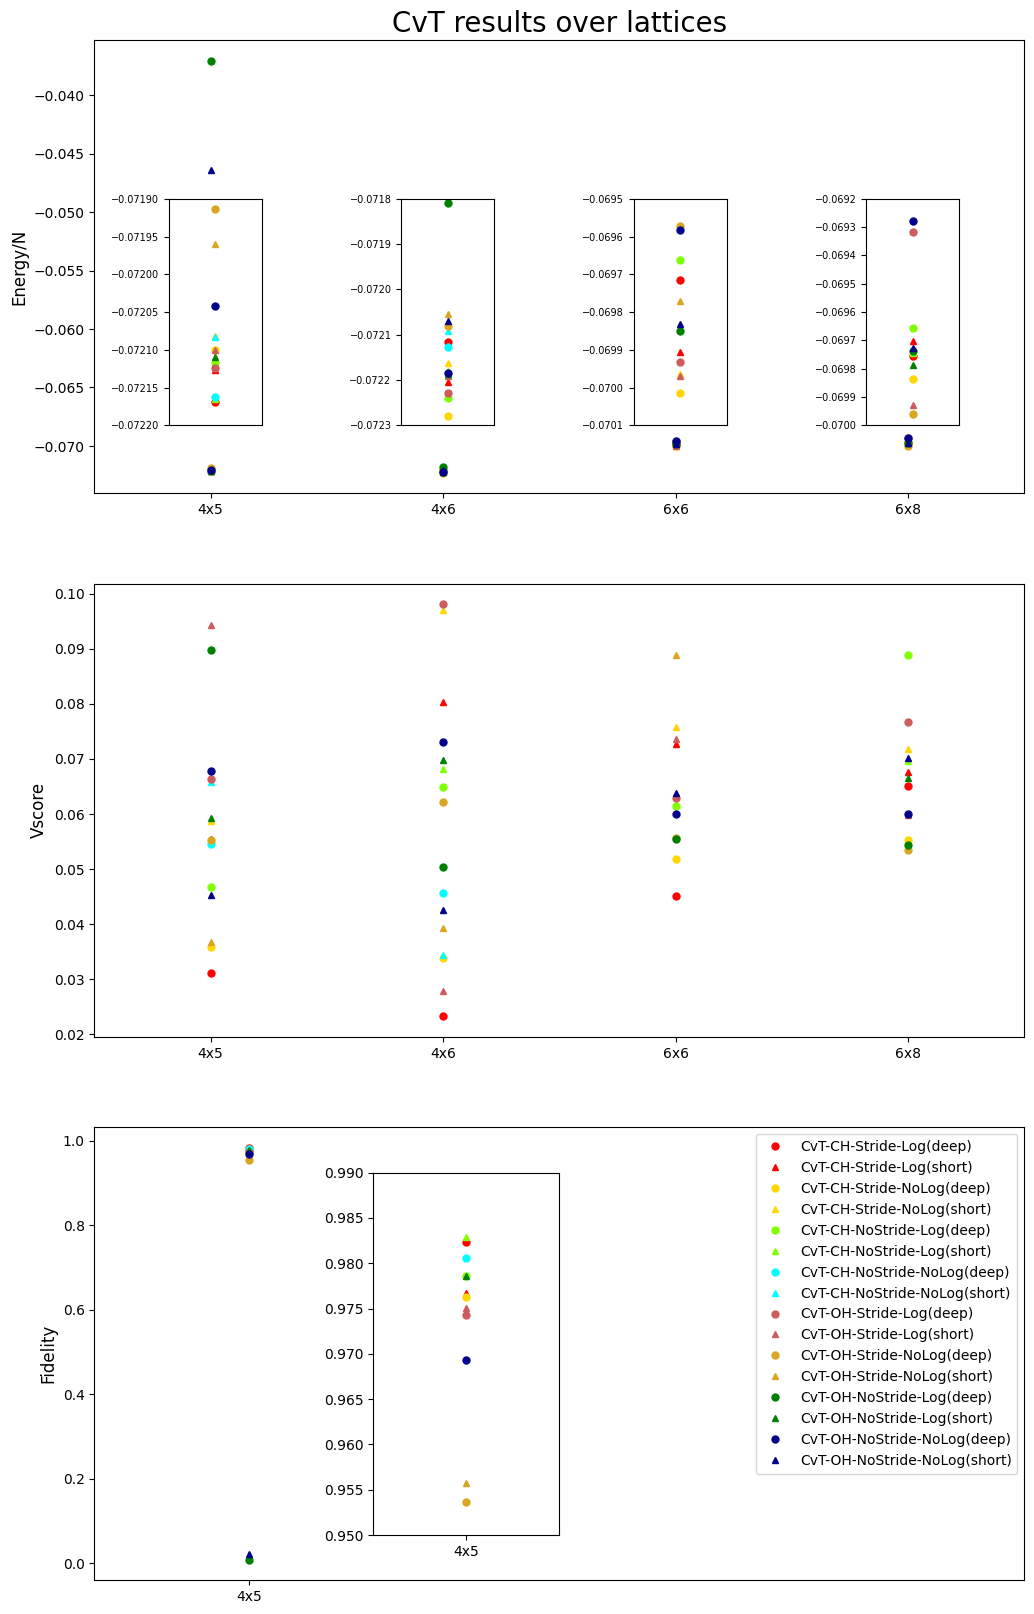

In [36]:
colors = ["red", "gold", "chartreuse", "cyan",  "indianred",  "goldenrod", "green", "darkblue" ]
markers = ["o","^"]

fig, ax = plt.subplots(3, 1, figsize=[12, 20])

axin0 = [ax[0].inset_axes(bounds=(0.08 + 0.25 * i, 0.15, 0.1, 0.5)) for i in range(len(sizes))]
for i in range(len(axin0)):
    axin0[i].set_xticks([], [])
    axin0[i].set_xlim(-0.5, 0.5)
    axin0[i].tick_params(axis="y", labelsize=7)

axin0[0].set_ylim(-0.0722, -0.0719)
axin0[1].set_ylim(-0.0723, -0.0718)
axin0[2].set_ylim(-0.0701, -0.0695)
axin0[3].set_ylim(-0.07, -0.0692)
# axin0 = ax[0].inset_axes(bounds=(0.4, 0.35, 0.58, 0.63))
# axin0.set_xticks(range(len(sizes)), sizes)
# axin0.set_xlim(-0.5, len(sizes)-0.5)
# axin0.set_ylim(-0.0725, -0.069)

axin2 = ax[2].inset_axes(bounds=(0.3, 0.1, 0.2, 0.8))
axin2.set_xticks(range(1), ["4x5"])
axin2.set_xlim(-0.5, 0.5)
axin2.set_ylim(0.95, 0.99)

for i in range(len(ax)-1):
    ax[i].set_xticks(range(len(sizes)), sizes)
    ax[i].set_xlim(-0.5, len(sizes)-0.5)

ax[2].set_xticks(range(1), ["4x5"])
ax[2].set_xlim(-0.1, 0.5)

ax[0].set_title("CvT results over lattices", fontsize=20)
ax[0].set_ylabel("Energy/N", fontsize=12)
ax[1].set_ylabel("Vscore", fontsize=12)
ax[2].set_ylabel("Fidelity", fontsize=12)

for m, mode in enumerate(modes):
    for s, size in enumerate(sizes):
        if size not in artifact_paths[mode]: continue
        for l, length in enumerate(["deep", "short"]):
            if length not in artifact_paths[mode][size]: continue
            ax[0].plot(s, energy[mode][size][length], color=colors[m], ls="", marker=markers[l], ms=5)
            axin0[s].plot(0, energy[mode][size][length], color=colors[m], ls="", marker=markers[l], ms=5)
            ax[1].plot(s, vscore[mode][size][length], color=colors[m], ls="", marker=markers[l], ms=5)
            if fidelity[mode][size][length] is not None:
                ax[2].plot(s, fidelity[mode][size][length], color=colors[m], ls="", marker=markers[l], ms=5, label=f"{mode}({length})")
                axin2.plot(s, fidelity[mode][size][length], color=colors[m], ls="", marker=markers[l], ms=5, label=f"{mode}({length})")

ax[2].legend(loc="best")                



In [2]:
path = "/home/ihuarte/Escritorio/Ivan/NNs/Irreps/"
with open(path + "config.json", "r") as f:
    config = json.load(f)

config_cm = config["config_cm"]

sizes = config_cm["sizes"]
size = sizes[0]

N = int(jnp.prod(jnp.array(size)))
hilbert = nk.hilbert.Spin(s=1 / 2, N=N, total_sz=None)

model_factory = ModelFactory(size, config_cm)

for params in model_factory.get_params():

    cm_model_setup = model_factory.get_setup()
    cm_model_name = model_factory.name

    print(f"\n************************ {cm_model_name} ************************")
    print(f"Size: {size}")
    print(f"Parameters: \n{params}")
    print(f"*************************************************************\n")

    cm_model = model_factory.get_model()
    eng = Runner(cm_model.cm, S_operators=False)
    E_ED, x_ED = eng.exact_energy_lanczos(hilbert, k = 3, eigenstates=True)

    sort_idx = np.argsort(E_ED)
    E_ED = E_ED[sort_idx]
    x_ED = x_ED.T[sort_idx]



************************ Oxalate ************************
Size: [4, 4]
Parameters: 
{'theta': 9.0, 'phi': 72.0, 'strength': 0.2}
*************************************************************



In [ ]:
labels = ["GroundState", "First Excited", "Second Excited", "Third Excited", "Fourth Excited", "Fifth Excited", "Sixth_excited"]

/home/ihuarte/Escritorio/Ivan/NNs/NN_module/dynamic_plots.py:281: SyntaxWarning: invalid escape sequence '\;'
  labels = [f"State\;\#{i}" for i in range(len(x_batch))]
/home/ihuarte/Escritorio/Ivan/NNs/NN_module/dynamic_plots.py:289: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/home/ihuarte/Escritorio/Ivan/NNs/NN_module/dynamic_plots.py:289: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/home/ihuarte/Escritorio/Ivan/NNs/NN_module/dynamic_plots.py:289: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[]

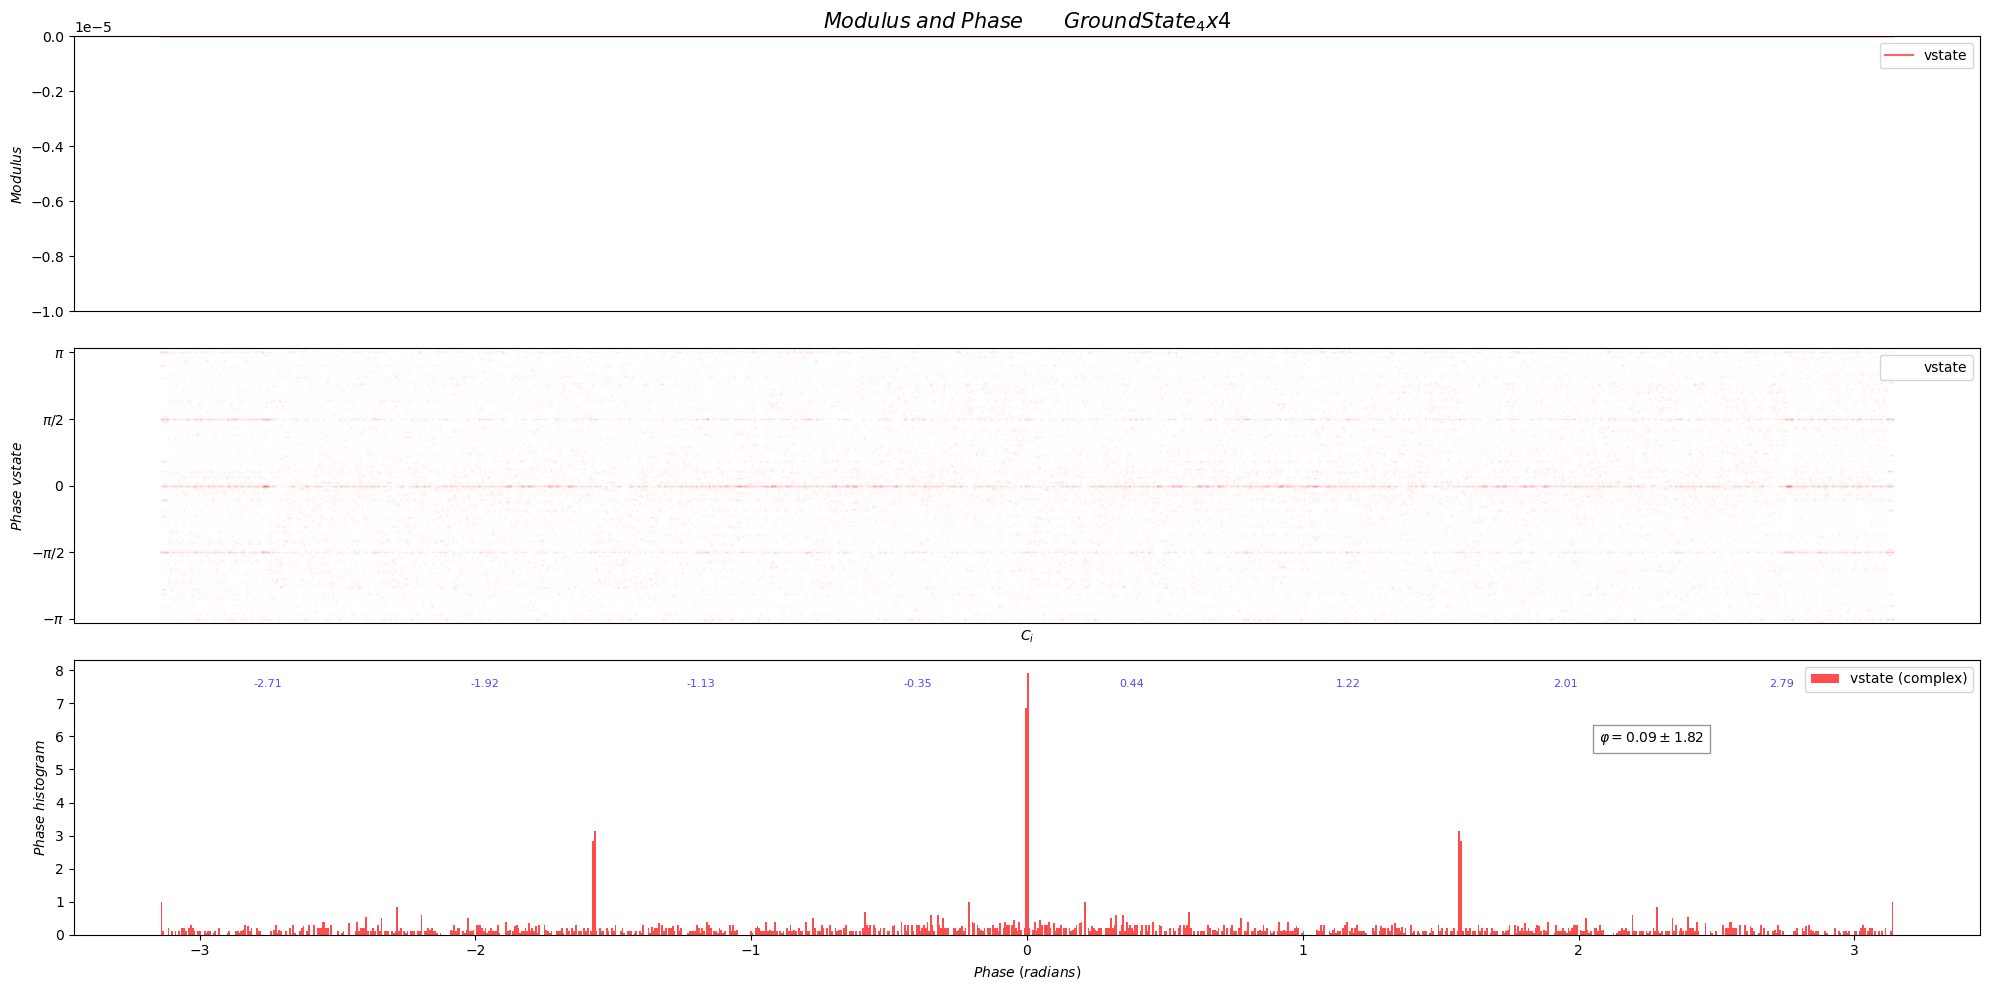

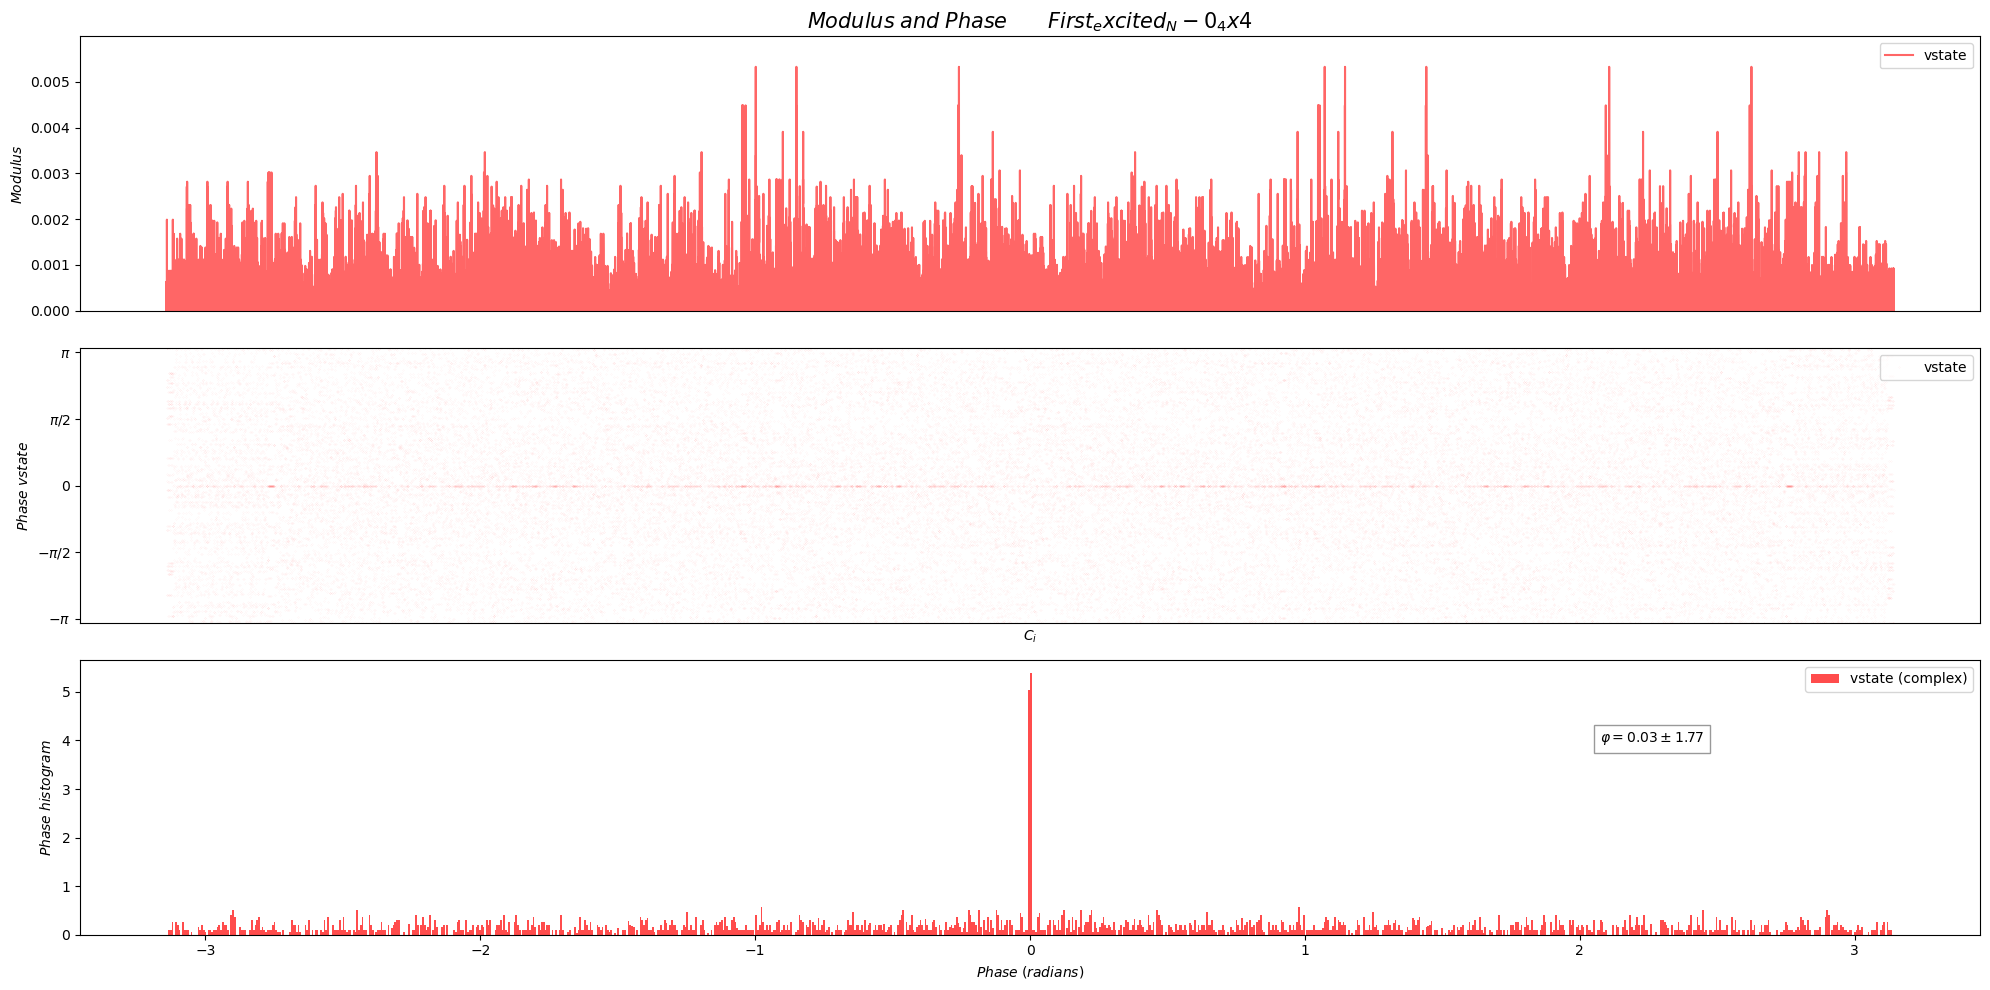

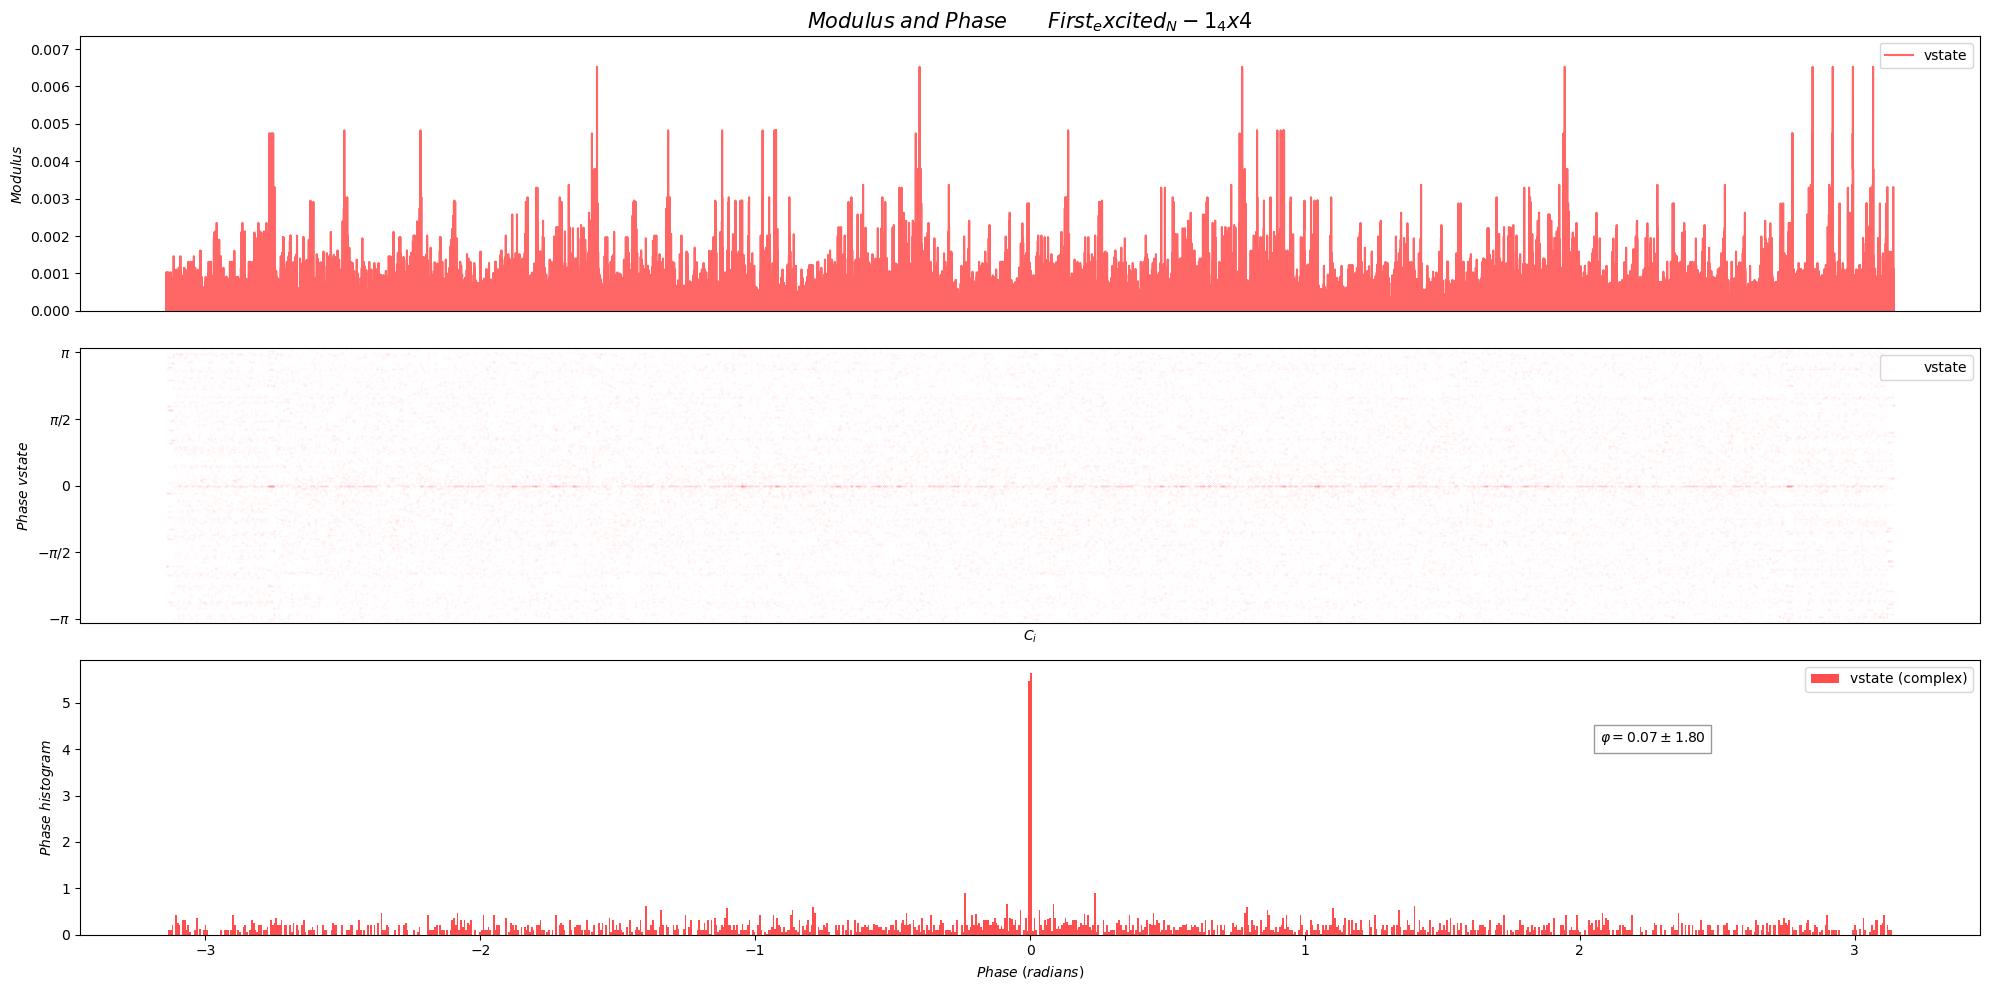

In [4]:
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

from NN_module.observables import modphase
from NN_module.dynamic_plots import batch_modphase_plotter

x_ED_Z2err = (x_ED - x_ED[:,::-1])

# list(batch_modphase_plotter(x_ED_Z2err, labels=labels, write_folder="/home/ihuarte/Escritorio/Ivan/NNs/3_states_study/modphase_Z2error/"))
x = x_ED[0]+x_ED[0, ::-1] 
x /= jnp.abs(x).sum()
list(batch_modphase_plotter(x_ED, labels=labels))



In [ ]:
a = jnp.ones((5,))
b = 2 * jnp.ones((5,))
jnp.stack([a,b], axis=1).mean(axis=1)

Array([1.5, 1.5, 1.5, 1.5, 1.5], dtype=float64)

: 

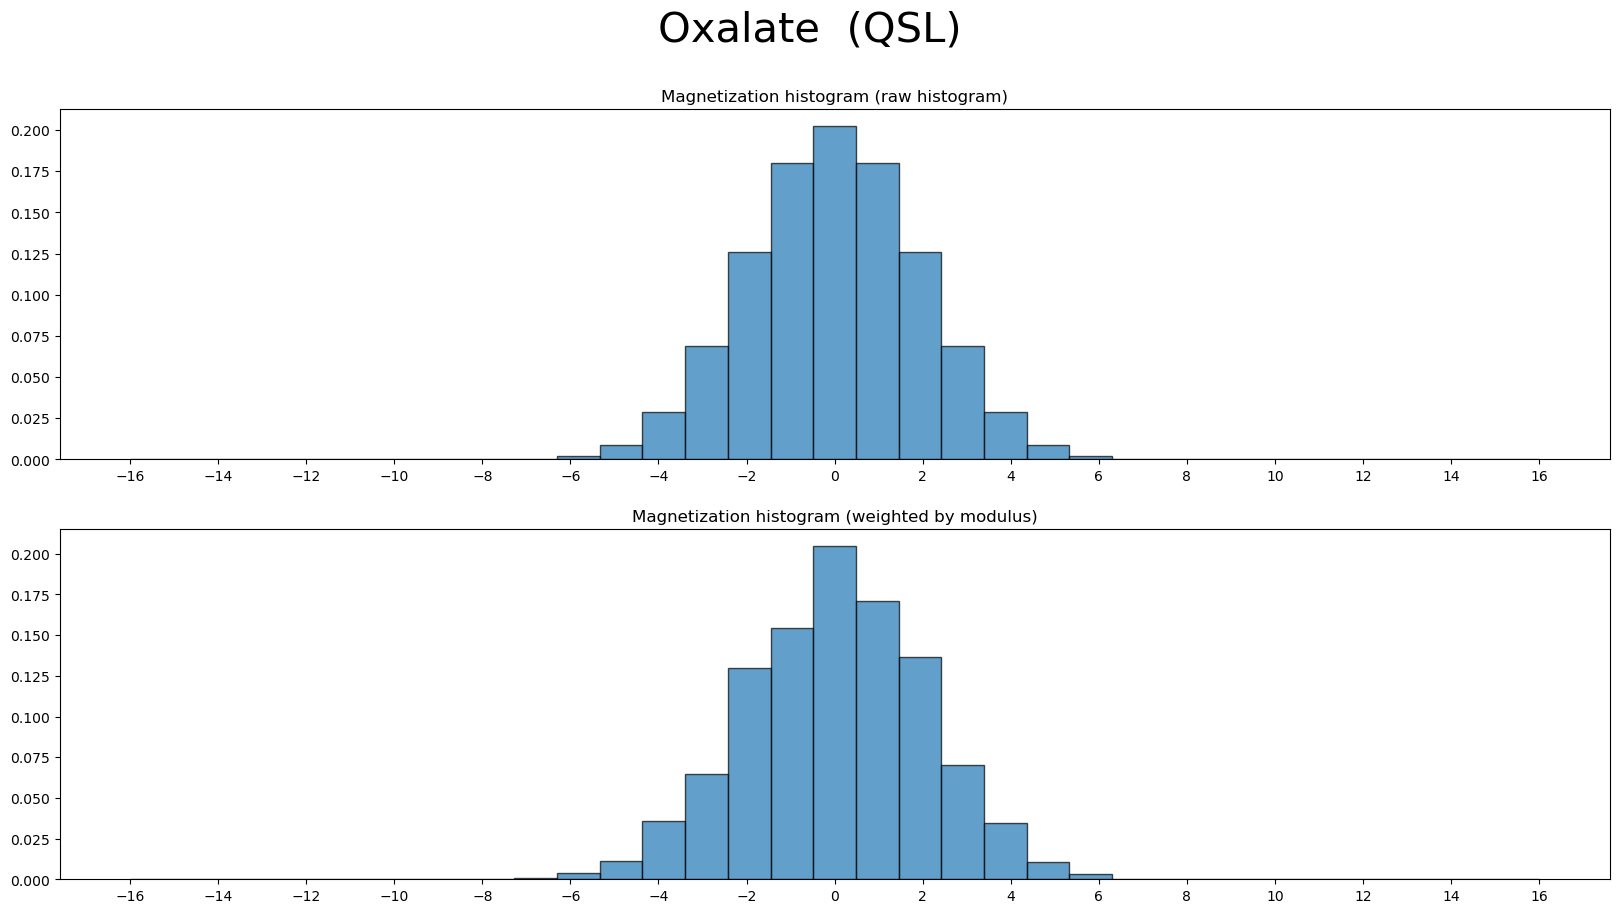

In [31]:
x = x_ED[2]

mod = jnp.abs(x)
phase = jnp.angle(x)
configs = hilbert.all_states()

max_contr_idx = jnp.argsort(mod)[::-1]
sorted_modulus = mod[max_contr_idx]
sorted_configs = configs[max_contr_idx, :]

config_magnetization = jnp.sum(sorted_configs, axis=-1)/2


import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1,  figsize=[20, 10])

fig.suptitle("J1-J2 Model  (J2/J1 = 0.5)", fontsize=30)
fig.suptitle("Oxalate  (QSL)", fontsize=30)

ax[0].set_title("Magnetization histogram (raw histogram)")
ax[1].set_title("Magnetization histogram (weighted by modulus)")
ax[0].hist(
    config_magnetization,
    bins=33,
    range=(-16, 16),
    density=True,
    alpha=0.7,
    label=f"ED",
    edgecolor='black',

)
ax[1].hist(
    config_magnetization,
    bins=33,
    range=(-16, 16),
    weights=sorted_modulus,
    density=True,
    alpha=0.7,
    label=f"ED",
    edgecolor='black',
    
)

ax[0].set_xticks(jnp.arange(-16,18,2))
ax[1].set_xticks(jnp.arange(-16,18,2))
# ax[0].set_yscale('log')
# ax[1].set_yscale('log')
# ax[0].set_ylim(1e-2, 1e2)
# ax[1].set_ylim(1e-2, 1e2)


In [16]:
from NN_module.observables import print_max_contributors

print_max_contributors(x_ED[0],(4,4), N_max=1000)

Config: 
[[-1 -1 -1 -1]
 [ 1  1  1  1]
 [-1 -1 -1 -1]
 [ 1  1  1  1]]
M = 0

Modulus: 0.06996695322537552
Phase: 1.1913023409460983

Config: 
[[ 1  1  1  1]
 [-1 -1 -1 -1]
 [ 1  1  1  1]
 [-1 -1 -1 -1]]
M = 0

Modulus: 0.06996695322537544
Phase: 1.1913023409461

Config: 
[[-1  1 -1  1]
 [-1  1 -1  1]
 [-1  1 -1  1]
 [-1  1 -1  1]]
M = 0

Modulus: 0.03953621103383934
Phase: 1.1913023409936798

Config: 
[[ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]
 [ 1 -1  1 -1]]
M = 0

Modulus: 0.039536211033838926
Phase: 1.1913023409936834

Config: 
[[ 1 -1  1 -1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]
 [-1  1 -1  1]]
M = 0

Modulus: 0.039536211033315456
Phase: 1.191302340994219

Config: 
[[-1  1 -1  1]
 [ 1 -1  1 -1]
 [-1  1 -1  1]
 [ 1 -1  1 -1]]
M = 0

Modulus: 0.03953621103331537
Phase: 1.191302340994218

Config: 
[[ 1  1 -1 -1]
 [-1 -1 -1 -1]
 [ 1  1  1  1]
 [-1 -1 -1 -1]]
M = -4

Modulus: 0.02945121774056104
Phase: 2.762098667734998

Config: 
[[ 1 -1 -1  1]
 [-1 -1 -1 -1]
 [ 1  1  1  1]
 [-1 -1 -1 -1]]
M 

In [ ]:
def testZ2(x, hilbert):
    (mod, phase), _ = modphase(x)

    M = np.array(hilbert.all_states().sum(axis=1))//2

    delta_phase = []

    for i, state in enumerate(hilbert.all_states()):

        i_inv = hilbert.states_to_numbers(-1.0 * state)
        # print(f"mod[{i}] = {mod[i]}  || mod[{i_inv}] = {mod[i_inv]}")

        assert np.isclose(mod[i], mod[i_inv], atol=1e-12)
        delta_phase.append(phase[i]-phase[i_inv])

    delta_phase = np.array(delta_phase)

    return M, delta_phase

M, Dphase = testZ2(x_ED[0], hilbert)


max_M = int(max(M))
M_indices = {}
for i in range(max_M + 1):
    M_indices[i] = np.where(M == i)[0]



0
1
2
3
4
5
6
7
8
{0: array([  255,   383,   447, ..., 65088, 65152, 65280], shape=(12870,)), 1: array([  127,   191,   223, ..., 64640, 64768, 65024], shape=(11440,)), 2: array([   63,    95,   111, ..., 63744, 64000, 64512], shape=(8008,)), 3: array([   31,    47,    55, ..., 61952, 62464, 63488], shape=(4368,)), 4: array([   15,    23,    27, ..., 58368, 59392, 61440], shape=(1820,)), 5: array([    7,    11,    13,    14,    19,    21,    22,    25,    26,
          28,    35,    37,    38,    41,    42,    44,    49,    50,
          52,    56,    67,    69,    70,    73,    74,    76,    81,
          82,    84,    88,    97,    98,   100,   104,   112,   131,
         133,   134,   137,   138,   140,   145,   146,   148,   152,
         161,   162,   164,   168,   176,   193,   194,   196,   200,
         208,   224,   259,   261,   262,   265,   266,   268,   273,
         274,   276,   280,   289,   290,   292,   296,   304,   321,
         322,   324,   328,   336,   352,   38

In [38]:
Dphase_per_M = {}

for m, indices in M_indices.items():
    Dphase_per_M[m] = Dphase[indices]


filtered = {}
for m, dphases in Dphase_per_M.items():
    tmp_filter = []
    for phase in dphases:
        if not any(np.isclose(phase, elem, atol=1e-12) for elem in tmp_filter):
            tmp_filter.append(phase)

    filtered[m] = np.array(tmp_filter)



In [45]:
Dphase_per_M[0][:20]

array([ 8.88178420e-16,  0.00000000e+00,  1.77635684e-15, -8.88178420e-16,
        0.00000000e+00,  7.78754838e-12,  6.66133815e-15, -7.79287745e-12,
        1.33226763e-14,  0.00000000e+00,  2.66453526e-15, -8.88178420e-16,
        8.88178420e-16, -1.37667655e-14, -7.79110110e-12, -2.66453526e-14,
        7.79110110e-12,  2.22044605e-15, -2.93987057e-11,  2.22044605e-15])

In [46]:
filtered[0]

array([ 8.88178420e-16,  7.78754838e-12, -7.79287745e-12, -2.93987057e-11,
        2.11229643e-01,  3.17122061e+00, -3.17122061e+00, -2.11229643e-01,
       -6.73665568e-11, -4.83474374e+00, -5.12771322e-02,  3.49180395e+00,
       -2.93071848e-01, -3.75985093e+00,  2.08697195e-01, -2.08697195e-01,
        3.75985093e+00,  2.93071848e-01, -3.49180395e+00,  5.12771322e-02,
        4.83474374e+00,  1.71507253e-12, -1.71196390e-12,  2.93924884e-11,
        6.73674450e-11, -2.67093548e+00,  5.28334289e+00, -3.22021719e+00,
        1.80537447e+00,  2.67093548e+00, -1.80537447e+00,  3.22021719e+00,
       -5.28334289e+00,  7.75809787e-01,  5.71827326e-01,  3.24229990e-01,
        1.18713928e-10,  4.78505916e-01,  5.73505687e-11, -1.85111706e+00,
       -4.57367477e-12, -1.06771036e-10, -7.75809787e-01, -5.62012659e-11,
       -3.24229990e-01,  1.85111706e+00, -4.78505916e-01, -5.71827326e-01,
        4.10959414e+00,  3.01733641e-01,  3.69097692e+00,  6.57110914e-01,
        7.58644787e-01, -

In [2]:
import json

from Irreps.utils import svds_orth
from VA_project.initialize_model import ModelFactory
from VA_project.engine.runners import Runner
from Irreps.SymmBuilder import SymmGroup, _all_idx_combinations


with open("/home/ihuarte/Escritorio/Ivan/NNs/Irreps/config.json", "r") as f:
    config = json.load(f)

write = config["write_folder"]
config_cm = config["config_cm"]
symmetries_config = config["symmetries"]

size = config_cm["sizes"][0]

N = int(jnp.prod(jnp.array(size)))
hilbert = nk.hilbert.Spin(s=1 / 2, N=N, total_sz=None)

model_factory = ModelFactory(size, config_cm)
params = model_factory.get_params().__next__()

print(f"\n************************ OXALATE ************************")
print(f"Size: {size}")
print(f"Parameters: \n{params}")
print(f"*************************************************************\n")

cm_model = model_factory.get_model()
eng = Runner(cm_model.cm, S_operators=model_factory.S_operators)

# Build the Hamiltonian
H = eng.build_hamiltonian(hilbert)

configurations = hilbert.all_states()
n_configurations = configurations.shape[0]

print(f"Initializing symmetry group...")

group = SymmGroup(
    symmetries_config, 
    lattice_size=size,
    all_states=configurations
)



************************ OXALATE ************************
Size: [3, 3]
Parameters: 
{'theta': 9.0, 'phi': 72.0, 'strength': 0.2}
*************************************************************

Initializing symmetry group...


In [ ]:
class OrbitDiagonalizer:
    def __init__(self, symm_group: SymmGroup, hilbert: nk.hilbert):
        self.symm_group = symm_group
        self.hilbert = hilbert
        self.g_dimensions = [subgroup.N for subgroup in self.symm_group.group]
        self.g_characters = self.group_character(self.symm_group.group)

        print("Computing group generators...")
        self.generators = self.get_idx_generators(symm_group.group, hilbert)

        print("Computing group orbits...")
        self.group_orbits = self.get_group_orbits(self.generators, hilbert.n_states, self.g_dimensions)

    def group_character(self, group):
        character = [symm.character for symm in group]
        def nruter(q,n):
            return jnp.array([char(q_i, n_i) for char, q_i, n_i in zip(character, q, n)], dtype=jnp.complex128).prod()
        return nruter        

    def get_idx_generators(self, group, hilbert):

        generators = []
        for symmetry in group:
            generator = hilbert.states_to_numbers(
                jax.vmap(lambda state: symmetry.operation(state))(hilbert.all_states())
            )
            generators.append(generator)

        return generators
    
    def power_generator(self, gen, idx, power):
        for _ in range(power):
            idx = int(gen[idx])
        return idx

    def get_group_orbits(self, generators, hilbert_dim: int, g_dimensions: Tuple[int]):

        orbits = []
        visited = set()

        for rep in range(hilbert_dim):
            if rep in visited:
                continue

            orbit = []

            for n_vector in _all_idx_combinations(g_dimensions):
                new_rep = rep
                for gen, n in zip(generators, n_vector):
                    new_rep = self.power_generator(gen, new_rep, n)
                orbit.append(new_rep)
                visited.add(new_rep)

            orbits.append(tuple(orbit))
        return orbits
    
    def build_irrep_basis(self, q_vector):

        q_basis = []

        n_vector = list(_all_idx_combinations(self.g_dimensions))
        # print(f"Building irrep basis for q_vector: {q_vector}...")

        for orbit in self.group_orbits:
            # print(f"Orbit: {orbit}")
            stabilizer_ns = [
                n_vector[k]
                for k, j in enumerate(orbit)
                if j == orbit[0] 
            ]

            # Stabilizer control
            if stabilizer_ns:
                # print(f"Stabilizer n_vector: {stabilizer_ns} ")
                    
                total = 0.0 + 0.0j
                for n in stabilizer_ns:
                    total += self.g_characters(q_vector, n)
                # print(f"Stabilizer control total: {total}")
                if jnp.abs(total) < 1e-12:
                    # print(f"Orbit is not in the irrep, skipping...\n")
                    continue
                # else:
                #     print("\n")

            # If the orbit contributes, we can build the basis vector

            state = {}
            for k, j in enumerate(orbit):
                n = n_vector[k]               
                state[j] = self.g_characters(q_vector, n)

            
            norm = jnp.sqrt(sum(jnp.abs(c)**2 for c in state.values()))
            for j in state:
                state[j] /= norm

            q_basis.append(state)

        return q_basis
    

    def apply_H_to_basis_index(self, H, j):
        # índice → configuración
        cfg = hilbert.numbers_to_states(int(j))

        # acción local del Hamiltoniano
        xs, mels = H.get_conn(cfg)

        out = {}
        for cfg_p, mel in zip(xs, mels):
            j_p = int(hilbert.states_to_numbers(cfg_p).item())
            out[j_p] = out.get(j_p, 0.0) + mel

        return out



    def apply_local_operator(self, H, state):
        """
        state: dict {hilbert_index: amplitude}
        """
        out = {}

        for j, amp in state.items():
            transitions = self.apply_H_to_basis_index(H, j)
            for jp, hval in transitions.items():
                out[jp] = out.get(jp, 0.0) + hval * amp

        return out



    def build_H_q_sparse(self, H, basis_q):
        dim_q = len(basis_q)
        H_q = jnp.zeros((dim_q, dim_q), dtype=jnp.complex128)

        # Precomputamos H |ψ_j⟩ en forma dispersa
        Hpsi = [
            self.apply_local_operator(H, state_j)
            for state_j in basis_q
        ]

        for i, psi_i in enumerate(basis_q):
            for j, Hpsi_j in enumerate(Hpsi):
                val = 0.0 + 0.0j
                # producto interno disperso
                for k, amp_i in psi_i.items():
                    if k in Hpsi_j:
                        val += jnp.conj(amp_i) * Hpsi_j[k]
                H_q = H_q.at[i, j].set(val)

        return H_q


    def diagonalize_by_blocks(self, hamiltonian, q_vectors=None):
        eigvals = {}
        eigvecs = {}
        
        q_vectors = q_vectors if q_vectors is not None else _all_idx_combinations(self.g_dimensions)

        basis = {}
        for q_vector in q_vectors:
            print(f"Diagonalizing for q_vector: {q_vector}...")
            print(f"Building irrep basis...")
            basis = self.build_irrep_basis(q_vector)
            print(f"Basis size for q_vector {q_vector}: {len(basis)}")

            print(f"Building H_q")
            H_q = self.build_H_q_sparse(hamiltonian, basis)
            print(f"H_q shape: {H_q.shape}")
            print(f"Diagonalizing H_q...")
            evals, evecs = sp.linalg.eigh(H_q)
            print(f"Diagonalization complete for q_vector\n")
            print(f"Eigenvalues for q_vector {q_vector}: {evals}\n")
            eigvals[q_vector] = evals
            eigvecs[q_vector] = evecs

        return eigvals, eigvecs
          


OD = OrbitDiagonalizer(group, hilbert)

Computing group generators...
Computing group orbits...


In [12]:
eigval, eigvec = OD.diagonalize_by_blocks(H)

Diagonalizing for q_vector: (0, 0)...
Building irrep basis...
Basis size for q_vector (0, 0): 64
Building H_q
H_q shape: (64, 64)
Diagonalizing H_q...
Diagonalization complete for q_vector

Eigenvalues for q_vector (0, 0): [-2.49462616 -2.49462616 -2.45596013 -2.45596013 -2.36924961 -2.36924961
 -1.94335308 -1.94335308 -1.7389682  -1.7389682  -1.62402273 -1.62402273
 -1.31346714 -1.31346714 -1.23830075 -1.23830075 -1.08718928 -1.08718928
 -1.08142073 -1.08142073 -0.87635813 -0.87635813 -0.74758989 -0.74758989
 -0.62064148 -0.62064148 -0.44994737 -0.44994737 -0.24916541 -0.24916541
 -0.11907821 -0.11907821 -0.00790924 -0.00790924  0.24482727  0.24482727
  0.48774603  0.48774603  0.50312118  0.50312118  0.60838497  0.60838497
  0.74929985  0.74929985  0.78332858  0.78332858  0.90248068  0.90248068
  1.0213541   1.0213541   1.12833591  1.12833591  1.48509997  1.48509997
  1.77616905  1.77616905  2.1432883   2.1432883   2.22381858  2.22381858
  2.98926283  2.98926283  4.7809738   4.7809738

E = [-2.49462616 -2.49462616 -2.45596013 -2.45596013 -2.36924961 -2.36924961
 -1.94335308 -1.94335308 -1.7389682  -1.7389682  -1.62402273 -1.62402273
 -1.31346714 -1.31346714 -1.23830075 -1.23830075 -1.08718928 -1.08718928
 -1.08142073 -1.08142073 -0.87635813 -0.87635813 -0.74758989 -0.74758989
 -0.62064148 -0.62064148 -0.44994737 -0.44994737 -0.24916541 -0.24916541
 -0.11907821 -0.11907821 -0.00790924 -0.00790924  0.24482727  0.24482727
  0.48774603  0.48774603  0.50312118  0.50312118  0.60838497  0.60838497
  0.74929985  0.74929985  0.78332858  0.78332858  0.90248068  0.90248068
  1.0213541   1.0213541   1.12833591  1.12833591  1.48509997  1.48509997
  1.77616905  1.77616905  2.1432883   2.1432883   2.22381858  2.22381858
  2.98926283  2.98926283  4.7809738   4.7809738 ]
E = [-2.31101197 -2.31101197 -2.21230732 -2.21230732 -2.04661102 -2.04661102
 -1.81531575 -1.81531575 -1.60112557 -1.60112557 -1.41952056 -1.41952056
 -1.16040187 -1.16040187 -0.98217863 -0.98217863 -0.91234442 -0.91

(-3.9497461585550733, 6.236093797059197)

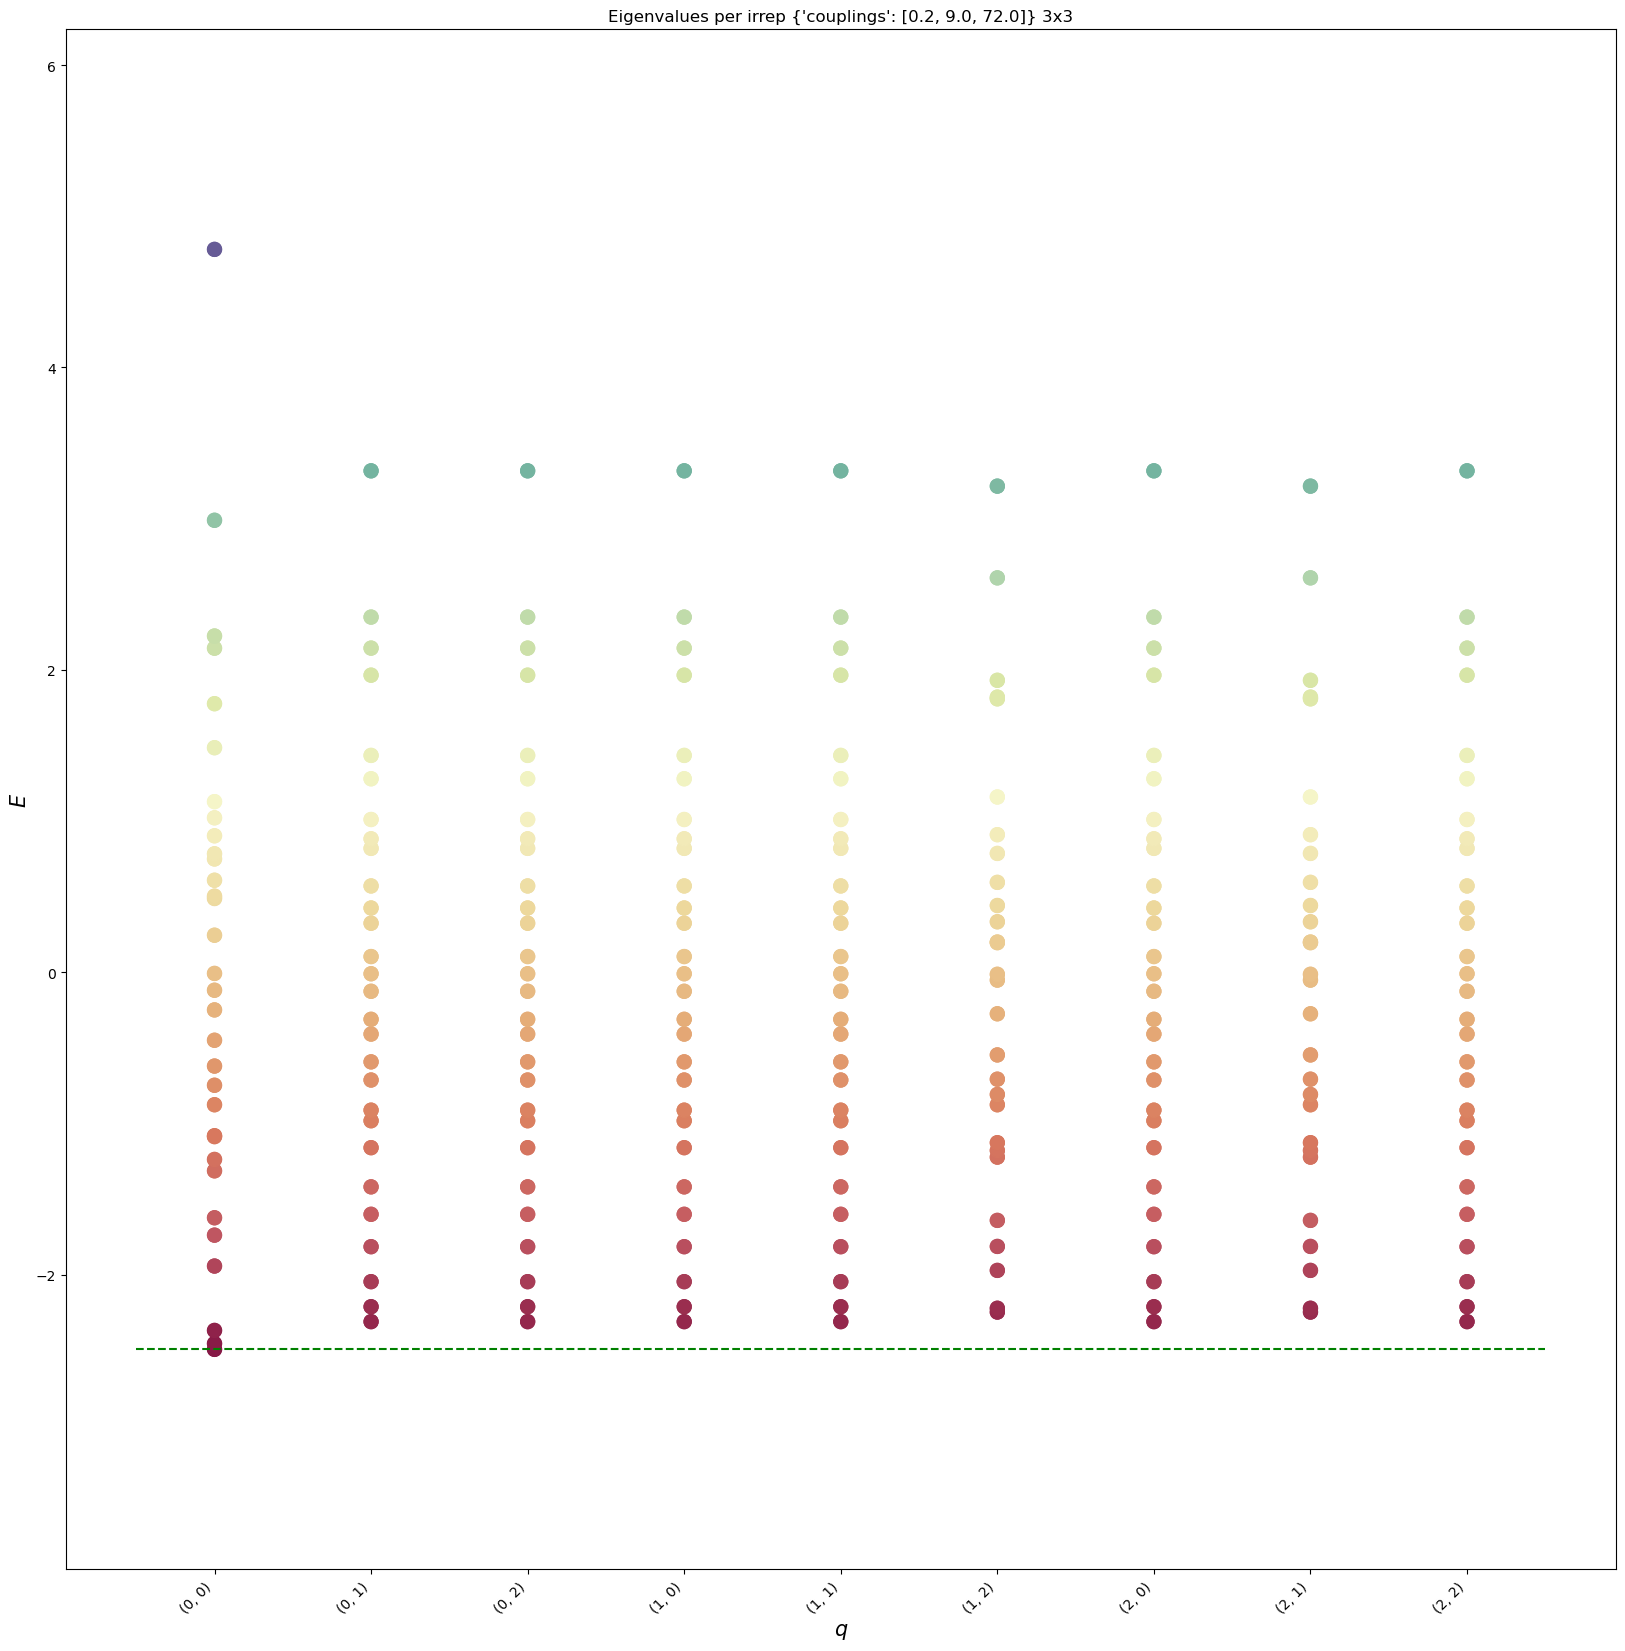

In [14]:
import matplotlib.colors as colors
import seaborn as sns
cmap = colors.LinearSegmentedColormap.from_list(
    "Spectral_soft", sns.color_palette("Spectral", 256, desat=0.7)
)
fig2, ax2 = plt.subplots(figsize=(20, 20))

global_min = np.inf
global_max = -np.inf
for i, q_vector in enumerate(_all_idx_combinations(OD.g_dimensions)):
    print("E =", eigval[q_vector])
    global_min = min(global_min, eigval[q_vector].min())
    global_max = max(global_max, eigval[q_vector].max())

for i, q_vector in enumerate(_all_idx_combinations(OD.g_dimensions)):
    ax2.scatter(
        [i] * len(eigval[q_vector]),
        eigval[q_vector],
        c=eigval[q_vector],
        cmap=cmap,
        vmin=global_min,
        vmax=global_max,
        label=f"{q_vector}",
        marker="o",
        s=100,
    )

ax2.set_title(
    f"Eigenvalues per irrep {params} {size[0]}x{size[1]}"
)
ax2.set_xlabel(r"$q$", fontsize=15)
ax2.set_ylabel(r"$E$", fontsize=15)
ax2.set_xticks(range(len(eigval)))
ax2.set_xticklabels([str(q) for q in eigval.keys()], rotation=45, ha="right")
span = global_max - global_min
ax2.hlines(global_min, -0.5, len(eigval) - 0.5, linestyles="dashed", color="green")
ax2.set_ylim(global_min - 0.2 * span, global_max + 0.2 * span)


Diagonalizing for q_vector: (0, 0)...
Building irrep basis...
Basis size for q_vector (0, 0): 4156
Building H_q


KeyboardInterrupt: 

In [ ]:
# Sanity check
for q_vector, basis in irrep_basis.items():
    print(f"q_vector: {q_vector}, basis size: {len(basis)}")

    for state in basis:
        assert jnp.allclose(sum(abs(c)**2 for c in state.values()), 1.0)

q_vector: (0, 0), basis size: 64
q_vector: (0, 1), basis size: 56
q_vector: (0, 2), basis size: 56
q_vector: (1, 0), basis size: 56
q_vector: (1, 1), basis size: 56
q_vector: (1, 2), basis size: 56
q_vector: (2, 0), basis size: 56
q_vector: (2, 1), basis size: 56
q_vector: (2, 2), basis size: 56


In [32]:
eigvals

{(0,
  0): array([-2.49462616, -2.49462616, -2.45596013, -2.45596013, -2.36924961,
        -2.36924961, -1.94335308, -1.94335308, -1.7389682 , -1.7389682 ,
        -1.62402273, -1.62402273, -1.31346714, -1.31346714, -1.23830075,
        -1.23830075, -1.08718928, -1.08718928, -1.08142073, -1.08142073,
        -0.87635813, -0.87635813, -0.74758989, -0.74758989, -0.62064148,
        -0.62064148, -0.44994737, -0.44994737, -0.24916541, -0.24916541,
        -0.11907821, -0.11907821, -0.00790924, -0.00790924,  0.24482727,
         0.24482727,  0.48774603,  0.48774603,  0.50312118,  0.50312118,
         0.60838497,  0.60838497,  0.74929985,  0.74929985,  0.78332858,
         0.78332858,  0.90248068,  0.90248068,  1.0213541 ,  1.0213541 ,
         1.12833591,  1.12833591,  1.48509997,  1.48509997,  1.77616905,
         1.77616905,  2.1432883 ,  2.1432883 ,  2.22381858,  2.22381858,
         2.98926283,  2.98926283,  4.7809738 ,  4.7809738 ]),
 (0,
  1): array([-2.31101197, -2.31101197, -2.21230

In [ ]:
from functools import partial


@partial(jax.jit, static_argnums=(2,))
def orbit_from_generator(generator, state_idx, dim):

    def orbit_runner(carry, _):
        new_idx = generator[carry]
        return new_idx, new_idx
    _, orbit_indices = jax.lax.scan(orbit_runner, state_idx, None, length=dim)


    return orbit_indices

# def get_symmetry_orbits(generators, dim)

orbit_from_generator(OD.generators[0], 20, group.group[0].N)


In [ ]:
def get_symmetry_orbits(generator, dim):

    all_orbits = jax.vmap(
        orbit_from_generator,in_axes=(None, 0, None)
        )(generator, jnp.arange(512, dtype=jnp.int32), g_dim)

    # Set the last column as the first one, and shift all the others to the right
    aux = all_orbits[:, -1]
    all_orbits = all_orbits.at[:, jnp.arange(1, g_dim)].set(all_orbits[:, :-1])
    all_orbits = all_orbits.at[:, 0].set(aux)

    # Make set of orbits unique
    orbit_set = jnp.unique(jnp.sort(all_orbits, axis=1), axis=0)

    return orbit_set

g_dim = group.group[0].N
orbit_set = get_symmetry_orbits(OD.generators[0], g_dim)


In [ ]:
size = (5,5)
N = size[0] * size[1]
x = jnp.arange(N)[None, :].reshape(size)

def rotate60_safe(lattice):
    Lx, Ly = lattice

    def nruter(x_in):
        rotated = jnp.zeros(lattice, dtype=jnp.int64)
        for i in range(Lx):
            for j in range(Ly):

                # coords reales
                x = i + 0.5 * j 
                y = (jnp.sqrt(3)/2) * j 

                # rotación 60°
                x_r = 0.5 * x - (jnp.sqrt(3)/2) * y 
                y_r = (np.sqrt(3)/2) * x + 0.5 * y 

                # volver a coords discretas
                j_new = int(round(y_r / (jnp.sqrt(3)/2)))
                i_new = int(round(x_r - 0.5 * j_new))

                i_new %= Lx
                j_new %= Ly
                
                rotated = rotated.at[i_new, j_new].set(x_in[i, j])

        return rotated
    return nruter

perm = rotate60_safe(size)
print(jnp.roll(x, shift=(2,2), axis=(0,1)))
y = perm(x)
jnp.roll(y, shift=(2,2), axis=(0,1))

In [ ]:
y

In [ ]:
jnp.roll(y, shift=(2,2), axis=(0,1))


In [ ]:
%run ./VMC_simulation.py

In [ ]:
B = 1
size=(6,6)
N = size[0]*size[1]

x = jnp.arange(N)[None, :]
x = jnp.ones(N)[None, :]
x = jnp.broadcast_to(x ,(B, N))

x = x.at[:,0].set(-1.0)

In [ ]:
vstate.model.apply(vstate.variables, x)

In [ ]:
a = jnp.ones((2,36))
b = jnp.arange(36)


In [ ]:
c = a*b
c, c.shape

In [ ]:
raw = jnp.array(
[[[10.61138765+22.84845978j, 11.61624836+23.58600621j,
   10.61138765+22.84845978j, 11.61624836+23.58600621j,
   10.61138765+22.84845978j, 11.61624836+23.58600621j],
  [11.37925431+23.38226749j, 11.06942364+23.10205822j,
   11.37925431+23.38226749j, 11.06942364+23.10205822j,
   11.37925431+23.38226749j, 11.06942364+23.10205822j],
  [10.61138765+22.84845978j, 11.61624836+23.58600621j,
   10.61138765+22.84845978j, 11.61624836+23.58600621j,
   10.61138765+22.84845978j, 11.61624836+23.58600621j],
  [11.37925431+23.38226749j, 11.06942364+23.10205822j,
   11.37925431+23.38226749j, 11.06942364+23.10205822j,
   11.37925431+23.38226749j, 11.06942364+23.10205822j],
  [10.61138765+22.84845978j, 11.61624836+23.58600621j,
   10.61138765+22.84845978j, 11.61624836+23.58600621j,
   10.61138765+22.84845978j, 11.61624836+23.58600621j],
  [11.37925431+23.38226749j, 11.06942364+23.10205822j,
   11.37925431+23.38226749j, 11.06942364+23.10205822j,
   11.37925431+23.38226749j, 11.06942364+23.10205822j]]], dtype=jnp.complex128
)

# real = jnp.where(raw.real > 1e-5, raw.real, 0.0)
# imag = jnp.where(raw.imag > 1e-7, raw.imag, 0.0)
# b = real + 1.0j * imag
# mod = jnp.abs(b)
# phase = jnp.angle(b)
# mod,phase/jnp.pi*180
# raw = raw - raw[0,0,0]
real = raw.real
imag = raw.imag

In [ ]:
raw

In [ ]:
%matplotlib inline
_, ax = plt.subplots(1, figsize=[10, 6])
ax.scatter(real.flatten(), imag.flatten(),)
ax.plot()
ax.set_xlabel("Real(z)")
ax.set_ylabel("Imag(z)")
ax.grid()
plt.show()

In [ ]:
mod = jnp.abs(raw)
phase = jnp.angle(raw)
i, j = jnp.unravel_index(jnp.arange(36), (6,6))
indices = jnp.array([i,j]).T.tolist()
indices = [str(ind) for ind in indices]
indices

In [ ]:



_, (ax1, ax2) = plt.subplots(2,1, figsize=[16, 16])
ax1.plot(range(36), mod.flatten(), ls='', marker='o', ms=3)
ax1.set_xticks(range(36))
ax1.set_xticklabels(indices, rotation=45, ha="right")
ax1.set_xlabel("Traslacion(z)")
ax1.set_ylabel("Modulo(z)")
ax1.grid()

ax2.plot(range(36), phase.flatten(), ls='', marker='o', ms=3)
ax2.set_xticks(range(36))
ax2.set_xticklabels(indices, rotation=45, ha="right")
ax2.set_xlabel("Traslacion(z)")
ax2.set_ylabel("Fase(z)")
ax2.set_ylim(-jnp.pi, jnp.pi)
ax2.grid()

axin = ax2.inset_axes(bounds=(0.25, 0.1, 0.4, 0.3) )
axin.plot(range(36), phase.flatten(), ls='', marker='o', ms=3)
axin.grid()

plt.show()

In [ ]:
from NN_module.NN.utils import setup_from_template
from NN_module.ST_utils import print_tree

template = config_nn[config_nn["selection"]]["stage0"]["template"]
storage = config_nn["storage"]
symm_wrapper = config_nn["symm_wrapper"]
print_tree(setup_from_template(template, storage, symm_wrapper), values=True)

hydra = Hydra(config_nn, **{"lattice_size": size})
model = hydra.model
params = model.init(jax.random.PRNGKey(0), jnp.ones((1, 36)))

code2path = hydra.get_code2path(params["params"])
code2path



In [ ]:
from NN_module.schedule.schedule import Schedule
#### INITIALIZE SCHEDULE ####
schedule_setup = config["schedule"]
schedule = Schedule(schedule_setup, code2path)
total_periods = schedule.total_periods
total_epochs = schedule.total_epochs
schedule_setup["total_epochs"] = total_epochs

In [ ]:

for i, (lr_period, info, change) in enumerate(schedule.schedule()):
    
    #### PRINT PERIOD INFO ####
    epochs = info[0][0]
    mode = info[0][1]
    lr_string = ""
    for inf in info:
        lr_string += f"{inf[2]}  "
    rescaled = "" if len(info) < 4 else info[3]
    print(f"\nPeriod {i + 1} / {total_periods}:")
    print(f"Training {mode} for {epochs} epochs")
    print(f"LR: {lr_string}  ({rescaled})")
    ###########################

    optimizer = schedule.transform_optimizer(
        params['params'], optax.sgd, info, lr_period
    )
    print(optimizer)


In [ ]:
schedule.eon_code2path

In [ ]:
from NN_module.NN import factory_submodule_tags, __all_single__
def get_code2path_tree(params, wraps=[], prefix=""):
    """
    Recursively builds a tree from a Flax/JAX pytree of parameters,
    assigning a unique positional index to each node.

    Each node is stored as:
        tree[name] = {
            "_idx": <hierarchical code>,
            "_children": { ... }
        }
    Indices are generated by concatenating child positions at each level:
        "0", "01", "010", etc.
    """
    if not isinstance(params, dict):
        # Hoja, retornamos vacío
        return {}
    
    

    tree = {}
    for i, (name, subtree) in enumerate(params.items()):
        if name in symm_submodule_dict.values():
            idx = f"{prefix}"
        else:
            idx = f"{prefix}{i}"
        tree[name] = {"_idx": idx, "_children": get_code2path_tree(subtree, prefix=idx)}
    return tree

def is_main_module(name):
    if "_" in name:
        name = name.split("_")[0]
    return name in factory_submodule_tags


def is_simple_module(raw_name):
    raw_name = raw_name[0]
    if "_" in raw_name:
        raw_name = raw_name.split("_")[0]
    if "Worker" in raw_name:
        raw_name = raw_name.split("Worker")[0]
    if "Block" in raw_name:
        raw_name = raw_name.split("Block")[0]

    if raw_name in __all_single__:
        return f"({raw_name})"
    else:
        return ""
def is_wrap(name):
    return name in symm_submodule_dict.values()

def print_architecture(tree, print_all=True, prefix="", is_last=True, wraps=[]):

    keys = list(tree.keys())

    for i, name in enumerate(keys):
        data = tree[name]
        last = i == len(keys) - 1
       
        iswrap = is_wrap(name)
        
        if iswrap:
             # Is Symm_Wrap
             
            children = list(data["_children"].keys())
            if len(children) == 1:
                child_name = children[0]
                if is_wrap(child_name):
                    print_architecture(data["_children"], print_all, prefix, is_last, wraps+[name])
                else:
                    wraps.append(name)
                    wrap_label = " ".join(wraps[1:]) if len(wraps) > 1 else print("No symmetrization")
                    print(f"SymmModel: ({wrap_label})")  if len(wraps) > 1 else print("SymmModel:")
                    print_architecture(data["_children"], print_all, prefix, is_last)
            else:
                wraps.append(name)
                wrap_label = " ".join(wraps[1:]) if len(wraps) > 1 else print("No symmetrization")
                print(f"SymmModel: ({wrap_label})")  if len(wraps) > 1 else print("SymmModel:")
                print_architecture(data["_children"], print_all, prefix, is_last)

        else:
                
            # Is factory
            is_main = is_main_module(name)
            children = list(data["_children"].keys())
            simple_module = ""
            if is_main:
                if len(children) == 1:
                    simple_module = is_simple_module(children)
                else:
                    candidates = [is_simple_module([child]) for child in children]
                    simple_module = next((c for c in candidates if c != ""), "")
            
            if not print_all and not is_main:
                continue

            annotation = ""
            if is_main and simple_module:
                annotation += f"{simple_module}"

            connector = "└── " if last else "├── "
            print(prefix + connector + f"{name} {annotation}  --->  ({data['_idx']})")

            if data["_children"] and not iswrap:
                new_prefix = prefix + ("    " if last else "│   ")
                print_architecture(
                    data["_children"], print_all, prefix=new_prefix, is_last=last
                )


In [ ]:
tree = get_code2path_tree(params["params"])
print_architecture(tree, print_all=False)

In [ ]:
print_tree(params)

In [ ]:

def c4_operation(lattice_size):
    def _operation(configuration):
        configuration = configuration.reshape(lattice_size).T[::-1]
        return configuration.reshape(-1)
    return _operation

class Cn():

    def __init__(self, lattice_size, n):
        """
        C_n rotation symmetry
        """

        self.lattice_size = lattice_size

        self.dim = 1
        self.N = 4
        self.character = lambda q, m: jnp.exp(2 * jnp.pi * q * m / n)

        assert self.N != 1, f"Group size too low. N = 1"
        assert all(L != 1 for L in self.lattice_size)

        if n == 4:
            self.operation = c4_operation(lattice_size)
        

    
class Refl_H():
    
    def __init__(self, lattice_size):
        """
        Reflection symmetry respect to the horizontal axis
        """

        self.lattice_size = lattice_size

        self.dim = 1
        self.N = 2
        self.character = lambda k, m: 1 if k==0 else (-1)**m

        assert self.N != 1, f"Group size too low. N = 1"
        assert all(L != 1 for L in self.lattice_size)

    def operation(self, configuration):
        return configuration.reshape(self.lattice_size)[::-1]
    
class Refl_V():
    
    def __init__(self, lattice_size):
        """
        Reflection symmetry respect to the horizontal axis
        """

        self.lattice_size = lattice_size

        self.dim = 1
        self.N = 2
        self.character = lambda k, m: 1 if k==0 else (-1)**m

        assert self.N != 1, f"Group size too low. N = 1"
        assert all(L != 1 for L in self.lattice_size)

    def operation(self, configuration):
        return configuration.reshape(self.lattice_size)[:, ::-1]

class Refl_D():
    
    def __init__(self, lattice_size):
        """
        Reflection symmetry respect to the horizontal axis
        """

        self.lattice_size = lattice_size

        self.dim = 1
        self.N = 2
        self.character = lambda k, m: 1 if k==0 else (-1)**m


        assert self.N != 1, f"Group size too low. N = 1"
        assert all(L != 1 for L in self.lattice_size)

    def operation(self, configuration):
        return configuration.reshape(self.lattice_size).T
    
class Refl_AD():
    
    def __init__(self, lattice_size):
        """
        Reflection symmetry respect to the horizontal axis
        """

        self.lattice_size = lattice_size

        self.dim = 1
        self.N = 2
        self.character = lambda k, m: 1 if k==0 else (-1)**m

        assert self.N != 1, f"Group size too low. N = 1"
        assert all(L != 1 for L in self.lattice_size)

    def operation(self, configuration):
        return configuration.reshape(self.lattice_size)[:, ::-1].T[:, ::-1]
    

In [ ]:
size = (3,3)
N = jnp.prod(jnp.array(size))
x = jnp.arange(N)
sym = Refl_AD(size)
x.reshape(size)

In [ ]:
x_1 = sym.operation(x)
x_1

In [ ]:
x_2 = sym.operation(x_1)
x_2

In [ ]:
x_3 = sym.operation(x_2)
x_3

In [ ]:
x_3 = sym.operation(x_3)
x_3

In [ ]:
        print(f"Subtype: {jnp.issubdtype(jnp.complex128, jnp.complexfloating)}")


In [5]:
import numpy as np
#oxalate
x_ED = np.loadtxt("/home/ihuarte/Escritorio/Ivan/NNs/new_pruebas/Oxalate/Factorized_CvT_Szabo_Transversal_Factorized/Size_4x4/ST_1000-A/UUID_4e71c27c/Oxalate_Factorized_CvT_Szabo_xED_4x4_strength_0.2_theta_9.0_phi_72.0.txt", dtype=complex)

# j1j2
# x_ED = np.loadtxt("/home/ihuarte/Escritorio/Ivan/NNs/new_pruebas/J1J2Square/Jastrow_Transversal_Jastrow_wrap/Size_4x4/ST_1500A/UUID_1b2e9d23/J1J2Square_Jastrow_xED_4x4_J1J2_1.0_0.5_XYZ_0.0_0.0_0.0.txt", dtype=complex)


In [6]:
size = (4,3)
a =0.2
theta = 9.0
phi = 72.0
cm_model = Oxalate(size, [a, theta, phi], order="default_2", bc='periodic')

eng = Runner(cm_model.cm, S_operators=True)
E_ED, x_ED = eng.exact_energy_lanczos(k=1, eigenstates=True)
x_ED=x_ED.flatten()

In [7]:
E_ED

array([-0.86797221])

In [8]:
mod = jnp.abs(x_ED)
phase = jnp.angle(x_ED)

no_null_mod_mask = mod > 1e-12
phase_mask = phase[no_null_mod_mask]

counts, values = jnp.histogram(phase, bins=1000000)
counts_mask, values_mask = jnp.histogram(phase_mask, bins=1000000)

weights = mod
counts_weighted, values_weighted = jnp.histogram(phase_mask, bins=1000000, weights=weights)


In [9]:
kde = sp.stats.gaussian_kde(phase, bw_method=0.01, weights=weights/jnp.sum(weights))

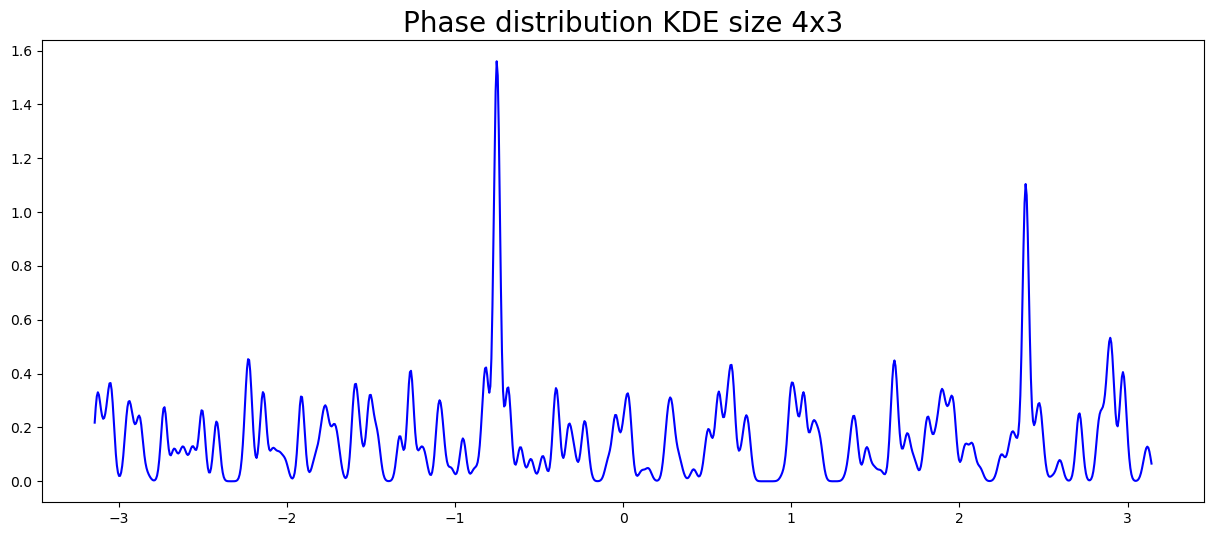

In [10]:
_, ax = plt.subplots(figsize=(15,6))
ax.set_title("Phase distribution KDE size " + f"{size[0]}x{size[1]}", fontsize=20)
ax.plot(jnp.linspace(-jnp.pi, jnp.pi, 1000), kde.evaluate(jnp.linspace(-jnp.pi, jnp.pi, 1000))[::-1], label="KDE with weights", color="blue")

(0.01, 100.0)

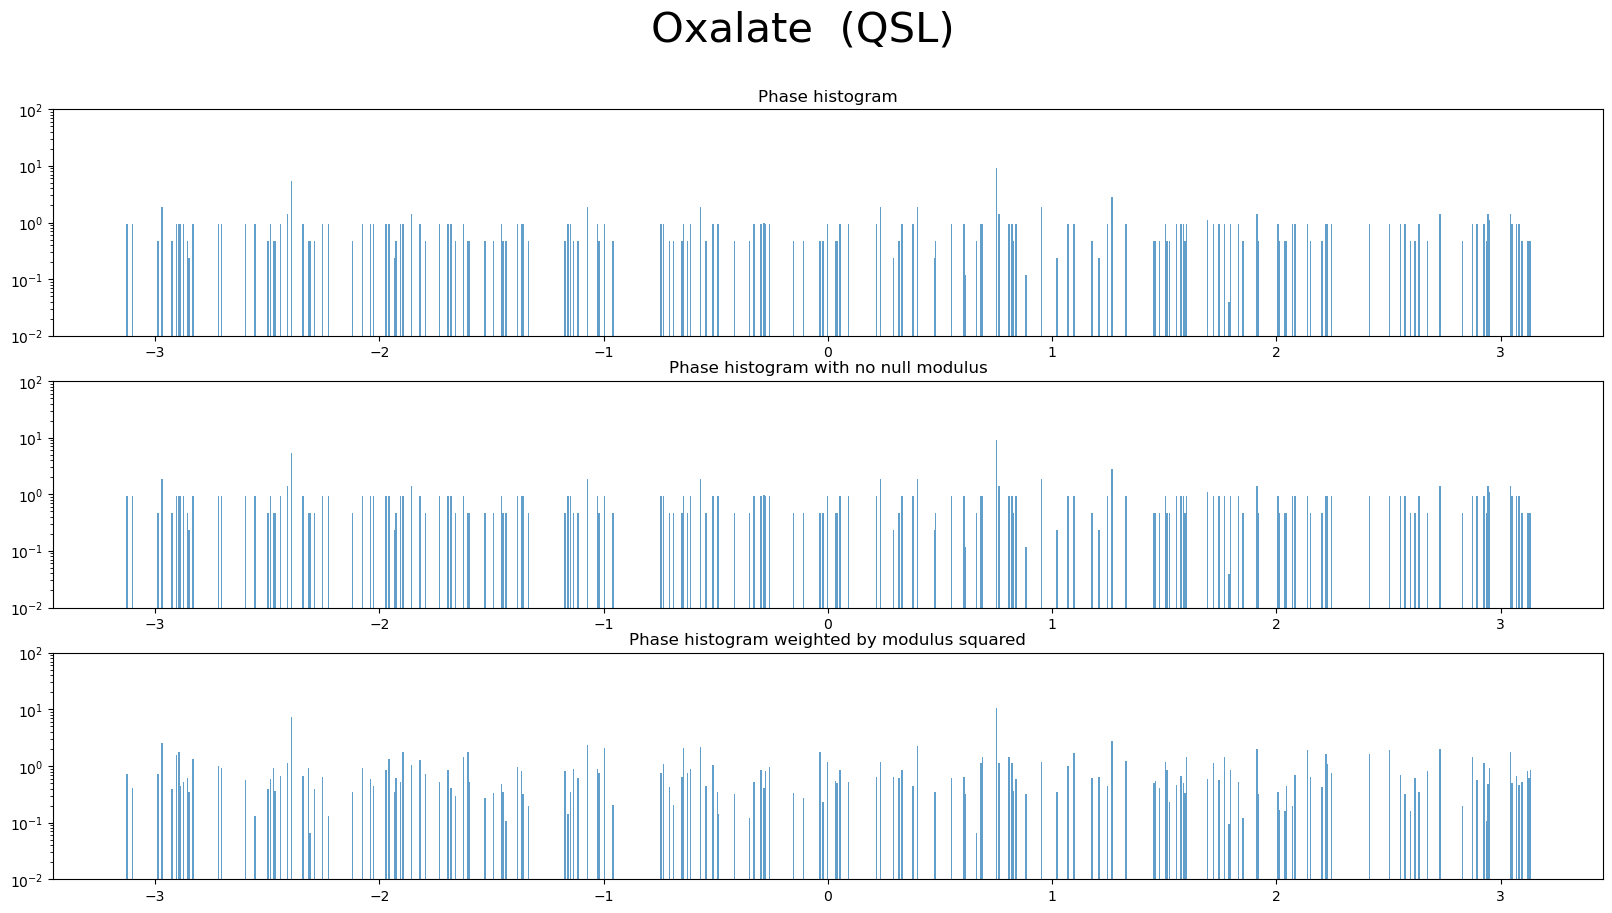

In [ ]:
import matplotlib.pyplot as plt

mod = jnp.abs(x_ED)
phase = jnp.angle(x_ED)

no_null_mod_mask = mod > 1e-12
phase_mask = phase[no_null_mod_mask]

counts, values = jnp.histogram(phase, bins=1000000)
counts_mask, values_mask = jnp.histogram(phase_mask, bins=1000000)

weights = mod
counts_weighted, values_weighted = jnp.histogram(phase_mask, bins=1000000, weights=weights)


fig, ax = plt.subplots(3, 1,  figsize=[20, 10])
ax[0].set_title("Phase histogram")
ax[1].set_title("Phase histogram with no null modulus")
ax[2].set_title("Phase histogram weighted by modulus squared")
ax[0].hist(
    phase,
    bins=1000,
    range=(-np.pi, np.pi),
    density=True,
    alpha=0.7,
    label=f"ED",
)
ax[1].hist(
    phase_mask,
    bins=1000,
    range=(-np.pi, np.pi),
    density=True,
    alpha=0.7,
    label=f"ED",
)
ax[2].hist(
    phase,
    bins=1000,
    range=(-np.pi, np.pi),
    weights=weights,
    density=True,
    alpha=0.7,
    label=f"ED",
)

ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[2].set_yscale('log')
ax[0].set_ylim(1e-2, 1e2)
ax[1].set_ylim(1e-2, 1e2)
ax[2].set_ylim(1e-2, 1e2)

In [ ]:
from NN_module.observables import all_spin_configurations

In [ ]:
def print_max_contributors(x, size, N_max=10, return_states=False):
    (mod, ph), _ = modphase(x)
    configs = all_spin_configurations(size[0] * size[1])

    idx = jnp.argsort(mod)[::-1][:N_max]
    max_configs = configs[idx, :]
    max_mods = mod[idx]
    max_phs = ph[idx]

    for config, mod, phs in zip(max_configs, max_mods, max_phs):
        tmagn = jnp.sum(config.flatten())
        print(f"Config: \n{config.reshape(size)}")
        print(f"M = {tmagn}")
        print(f"\nModulus: {mod}")
        print(f"Phase: {phs}\n")

    if return_states:
        return max_configs

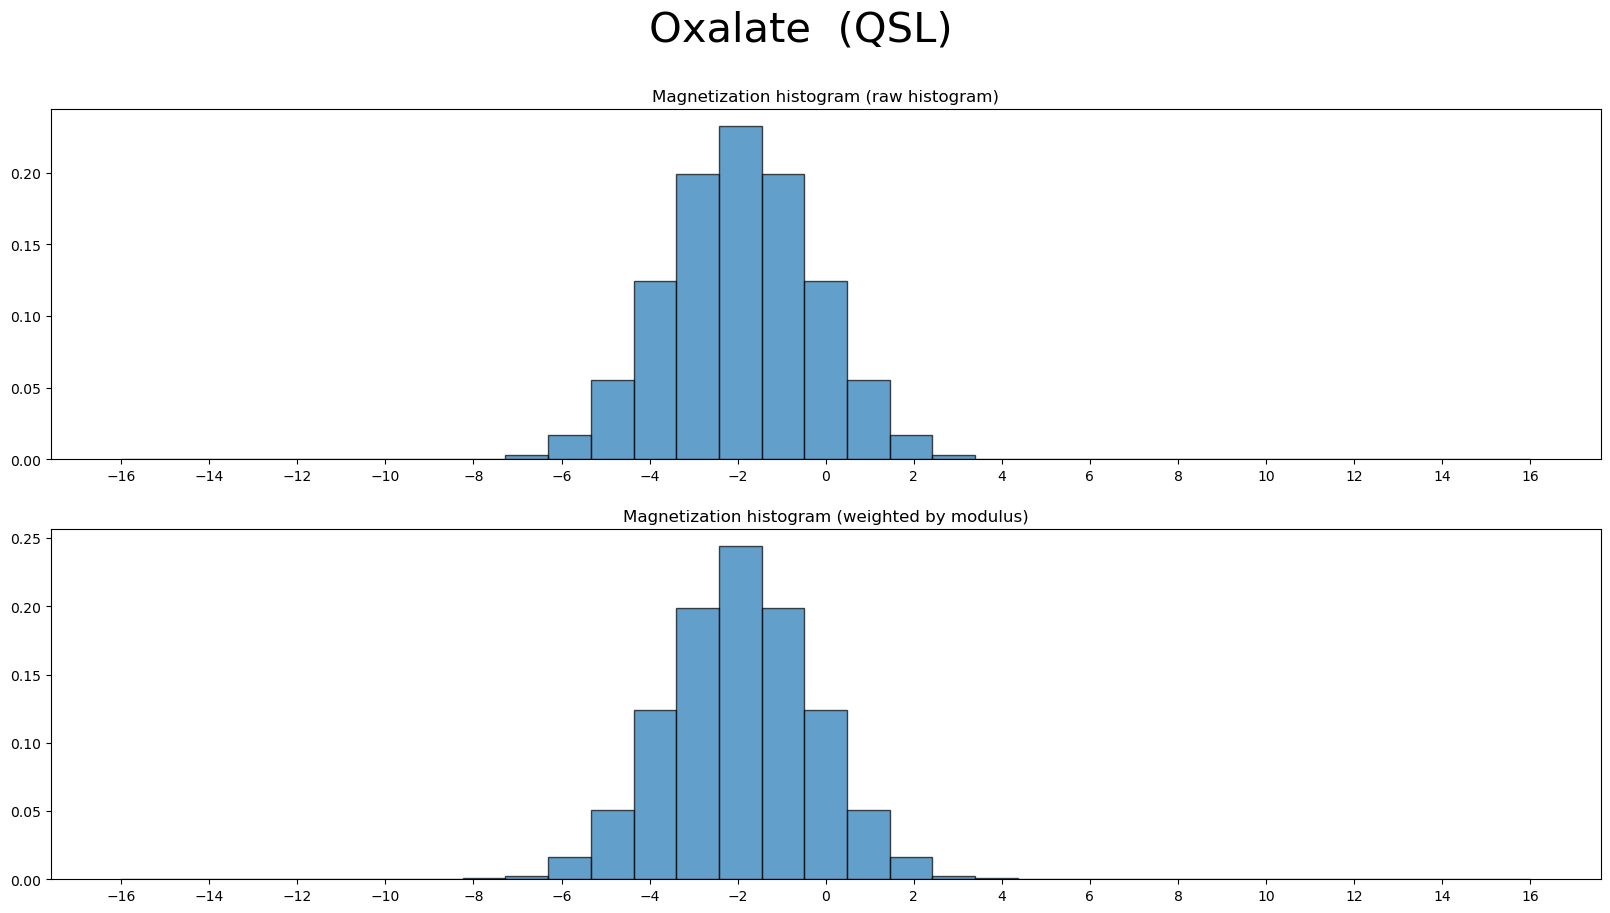

In [13]:
from NN_module.observables import all_spin_configurations
size = (4,4)
mod = jnp.abs(x_ED)
phase = jnp.angle(x_ED)
configs = all_spin_configurations(size[0] * size[1])

max_contr_idx = jnp.argsort(mod)[::-1]
sorted_modulus = mod[max_contr_idx]
sorted_configs = configs[max_contr_idx, :]

config_magnetization = jnp.sum(sorted_configs, axis=-1)/2


import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1,  figsize=[20, 10])

fig.suptitle("J1-J2 Model  (J2/J1 = 0.5)", fontsize=30)
fig.suptitle("Oxalate  (QSL)", fontsize=30)

ax[0].set_title("Magnetization histogram (raw histogram)")
ax[1].set_title("Magnetization histogram (weighted by modulus)")
ax[0].hist(
    config_magnetization,
    bins=33,
    range=(-16, 16),
    density=True,
    alpha=0.7,
    label=f"ED",
    edgecolor='black',

)
ax[1].hist(
    config_magnetization,
    bins=33,
    range=(-16, 16),
    weights=sorted_modulus,
    density=True,
    alpha=0.7,
    label=f"ED",
    edgecolor='black',
    
)

ax[0].set_xticks(jnp.arange(-16,18,2))
ax[1].set_xticks(jnp.arange(-16,18,2))
# ax[0].set_yscale('log')
# ax[1].set_yscale('log')
# ax[0].set_ylim(1e-2, 1e2)
# ax[1].set_ylim(1e-2, 1e2)


In [ ]:
max(mod), min(mod)

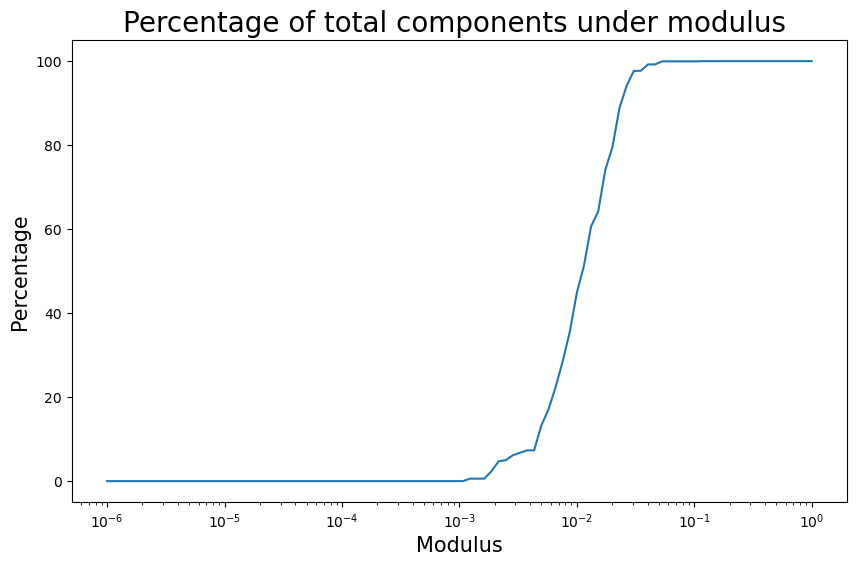

In [14]:
tramos = jnp.logspace(-6, 0, 100)
perc_under_x = []

for x in tramos:
    perc_under_x.append((sorted_modulus < x).sum()/sorted_modulus.shape[0] * 100)

    
_, ax = plt.subplots(figsize=(10,6))
ax.plot(tramos, perc_under_x)
ax.set_title("Percentage of total components under modulus ", fontsize=20)
ax.set_xlabel("Modulus", fontsize=15)
ax.set_ylabel("Percentage", fontsize=15)
ax.set_xscale('log')

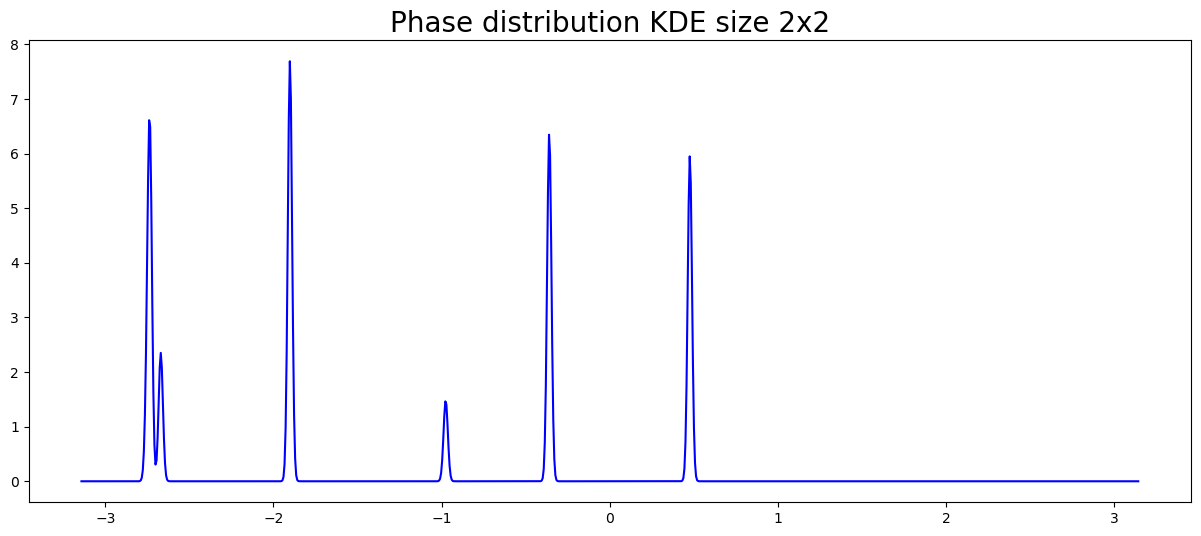

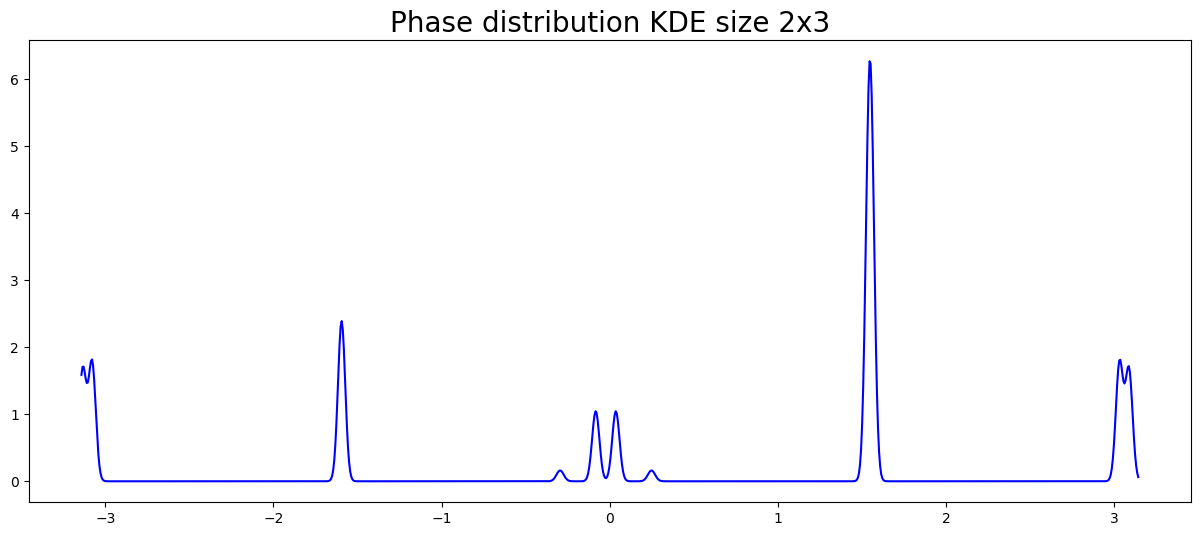

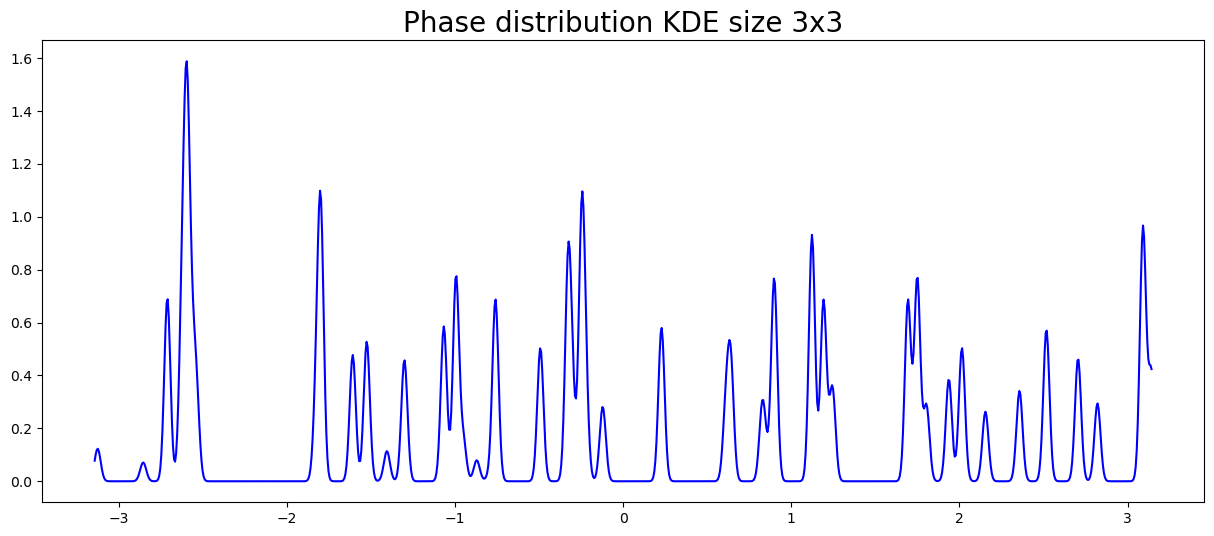

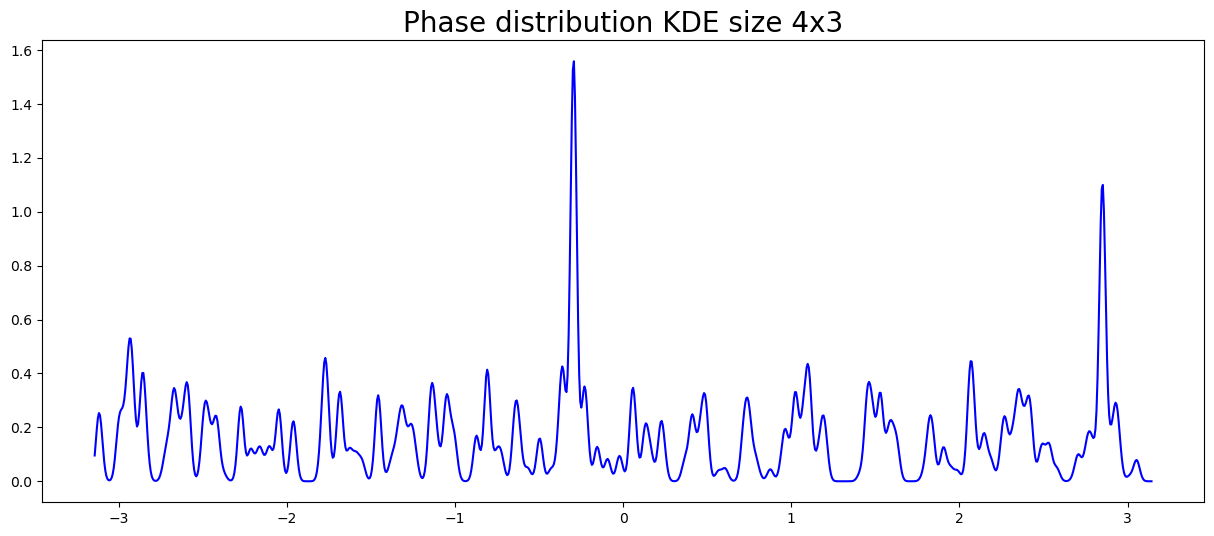

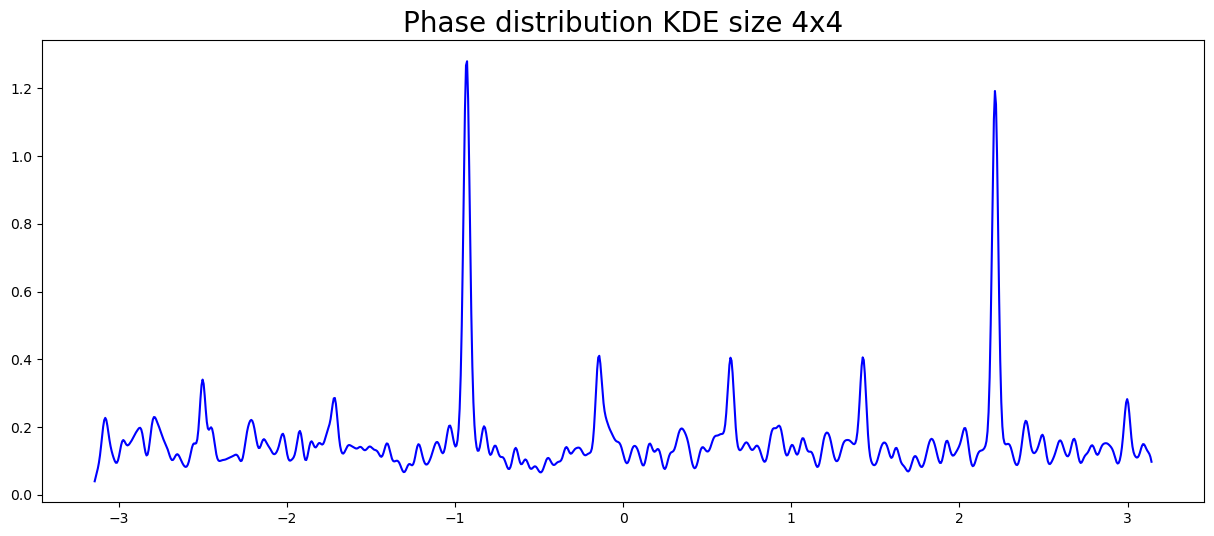

KeyboardInterrupt: 

In [15]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import scipy as sp
from VA_project.model.model import J1J2Square, Oxalate
from VA_project.engine.runners import Runner

size = (4,3)
a =0.2
theta = 9.0
phi = 72.0

for size in [(2,2), (2,3), (3,3), (4,3), (4,4), (4,5)]:
    cm_model = Oxalate(size, [a, theta, phi], order="default_2", bc='periodic')

    eng = Runner(cm_model.cm, S_operators=True)
    E_ED, x_ED = eng.exact_energy_lanczos(k=1, eigenstates=True)
    x_ED=x_ED.flatten()
    mod = jnp.abs(x_ED)
    phase = jnp.angle(x_ED)
    weights = mod
    kde = sp.stats.gaussian_kde(phase, bw_method=0.01, weights=weights/jnp.sum(weights))

    _, ax = plt.subplots(figsize=(15,6))
    ax.set_title("Phase distribution KDE size " + f"{size[0]}x{size[1]}", fontsize=20)
    ax.plot(jnp.linspace(-jnp.pi, jnp.pi, 1000), kde.evaluate(jnp.linspace(-jnp.pi, jnp.pi, 1000))[::-1], label="KDE with weights", color="blue")
    plt.show()
    plt.close()

In [ ]:
import glob
from NN_module.saveNload import load_pytree
from NN_module.observables import distance_with_neel, distance_with_stripped
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import jax.numpy as jnp
size = (10,10)
neel = distance_with_neel(size)
stripped = distance_with_stripped(size)

parent = "/home/ihuarte/Escritorio/Ivan/NNs/pruebas/Neel/"
paths_list = glob.glob(parent + "**/*_results_*.json", recursive=True)

for path in paths_list:

    with open(path, 'r') as f:
        artifact = json.load(f)

    param_path =artifact["_artifacts"]["parameters"]
    callback_path = artifact["_artifacts"]["callback"]["plot"]

    img = mpimg.imread(callback_path)
    plt.figure(figsize=(15,15))
    plt.imshow(img)
    plt.axis('off')  
    plt.show()

    parameters = load_pytree(param_path)
    print("\n")
    print(f"File: {path}")
    print(parameters)
    parameters = parameters['Trans_0']['phi'].reshape(size)
    filtered_params = jnp.where(parameters < 0, -1, 1)
    print(filtered_params) 

    dist_neel, neel_label = neel(filtered_params)
    dist_strip, strip_label = stripped(filtered_params)

    print("\n")
    print(f"Distance with Neel:     {dist_neel} ({neel_label})")
    print(f"Distance with Stripped: {dist_strip} ({strip_label})")

    print("\n")